# Credit Cycle & Inventory Analytics for a Consumer Durables Distributor
## Part 2: Revisiting the analysis with advanced methods (2026)
### Case study: Anuratna Corporation, Jaipur (authorised Sansui distributor)

**Author:** Bhavya Sharma, BS in Data Science & Applications, IIT Madras

---

[Part 1](anuratna_part1_descriptive_analysis.ipynb) was my Business Data Management capstone (awarded Best Project). It described the firm's credit and stock problems with standard tools and ended with a set of recommendations and open questions. In 2026 I came back to the project with methods I had learned since (survival analysis, causal inference, simulation, experiment design and optimisation) to test those conclusions on the same data.

### The business, briefly

Anuratna Corporation buys Sansui TVs and washing machines and sells them to about 29 retailers in Jaipur on **30-day credit** (cycle 1 = days 1-30, cycle 2 = 31-60, cycle 3 = 61-90). It pays Sansui up front and earns a thin, fixed margin of about 6-8%, so every day a dealer pays late is a day the distributor is financing that dealer's shop. The proprietor's problems: **long credit cycles**, **poor investment rotation** (money stuck in the wrong stock), and **price wars** (which Part 1 showed the firm can't fight, since Sansui is already the cheapest or near-cheapest brand).

### What Part 1 concluded

* The share of dealers who cleared their dues fell from **82.8% to 55.2% to 37.9%**, while paying dealers' median time to pay stayed flat at **~56.5 days**.
* A logistic regression flagged late invoices with **ROC-AUC ~0.80**, driven by each dealer's average days to pay.
* **Recommended:** a 3% discount for paying within 30 days and a 9% penalty after; tighter follow-up of problem dealers; more stock investment in models with growing sales; exploring invoice financing.

It also left open questions: Are recent periods worse only because they've had less time to be paid? Does ignoring unpaid invoices hide how slow payment is? Was the model using information it wouldn't have had at the time? Would the discount and penalty make or lose money? Which models are really gaining ground?

### What this notebook does

| Part 1 question | Method used here |
|---|---|
| Are the payment metrics fair across periods? | **Survival analysis**: Kaplan-Meier with unpaid invoices as censored observations, log-rank test, dealer-level bootstrap |
| What really drives slow payment? | **Cox proportional hazards**, plus a fixed-effects regression that reveals a Simpson's paradox |
| Can late payment be predicted honestly? | **Point-in-time features**, **out-of-time validation**, logistic scorecard vs gradient boosting |
| Do the discount and penalty pay off? | **Monte Carlo simulation** of credit policies with dealer behaviour and parameter uncertainty |
| Which models are really gaining ground? | **Mann-Kendall trend tests** on each model's share of sales |
| How should the stock budget be spent? | **Forecast backtesting** (Holt-Winters, Theta, top-down) feeding a **stochastic linear program** |
| How should changes be rolled out? | **Pilot design** with stratified randomisation and simulation-based **power analysis** |

**Contents:** 0 Setup · 1 Load & clean · 2 Why Part 1's payment metrics mislead · 3 Survival analysis · 4 Risk model & scorecard · 5 Dealer segments · 6 Credit-policy simulation · 7 Demand trends · 8 Stock optimisation · 9 Part 1 vs Part 2 · 10 Action plan & pilot test · 11 Expected outcomes · 12 Limitations

> **Data:** the firm's data is confidential; this notebook is shown on a representative dataset that reproduces its summary figures.

## Glossary

| Term | Meaning here |
|---|---|
| **Censored observation** | An invoice still unpaid when the data was pulled. We don't know when it will be paid, only that it has taken at least this long |
| **Kaplan-Meier curve** | Share of invoices paid by each day after invoicing, using censored invoices correctly |
| **Hazard ratio (HR)** | From a Cox model. HR < 1 means a factor makes payment slower, HR > 1 faster |
| **Point-in-time feature** | A feature computed only from information available on the day the invoice was raised |
| **ROC-AUC** | How well a model ranks risky invoices above safe ones. 0.5 = coin flip, 1.0 = perfect |
| **Credit scorecard** | A model converted to points (here 600 = even odds of paying within 60 days; +20 points doubles the odds) |
| **Monte Carlo simulation** | Re-running a calculation thousands of times with random but plausible inputs to see the range of outcomes |
| **Mann-Kendall test** | A test of whether a series trends up or down over time, without assuming a straight line |
| **WAPE** | Forecast error: total absolute error / total actual sales |
| **Linear program (LP) / shadow price** | An optimisation that picks quantities to maximise profit under constraints; the shadow price is the extra profit from one more rupee of budget |
| **Statistical power** | The probability that a test detects an effect of a given size if it is really there |

## 0. Setup

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import linprog
from scipy.sparse import coo_matrix, hstack, vstack, csr_matrix

import statsmodels.api as sm
from statsmodels.duration.hazard_regression import PHReg
from statsmodels.duration.survfunc import survdiff
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 100
SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
# works on Kaggle, Colab (upload the folder to /content) or locally
if os.path.exists('/kaggle/input/anuratna-distribution-data'):
    DATA = '/kaggle/input/anuratna-distribution-data'
elif os.path.exists('/content/anuratna-distribution-data'):
    DATA = '/content/anuratna-distribution-data'
else:
    DATA = 'input/anuratna-distribution-data'

for dirname, _, filenames in os.walk(DATA):
    for f in sorted(filenames):
        print(os.path.join(dirname, f))

input/anuratna-distribution-data/competitor_prices.csv
input/anuratna-distribution-data/dealer_master.csv
input/anuratna-distribution-data/invoice_items.csv
input/anuratna-distribution-data/payment_receipts.csv
input/anuratna-distribution-data/product_master.csv
input/anuratna-distribution-data/sales_invoices.csv


## 1. Load and clean the data

Same files and cleaning steps as Part 1.

In [3]:
dealers   = pd.read_csv(f'{DATA}/dealer_master.csv')
invoices  = pd.read_csv(f'{DATA}/sales_invoices.csv')
receipts  = pd.read_csv(f'{DATA}/payment_receipts.csv')
items     = pd.read_csv(f'{DATA}/invoice_items.csv')
products  = pd.read_csv(f'{DATA}/product_master.csv')
comp      = pd.read_csv(f'{DATA}/competitor_prices.csv')

for name, df in [('dealers', dealers), ('invoices', invoices), ('receipts', receipts),
                 ('items', items), ('products', products), ('competitor prices', comp)]:
    print(f'{name:18s} {df.shape}')

dealers            (29, 6)
invoices           (1231, 5)
receipts           (1045, 5)
items              (4073, 6)
products           (18, 7)
competitor prices  (62, 5)


In [4]:
invoices.head()

,invoice_no,invoice_date,dealer_code,invoice_amount,credit_days
0,AC/00002,03-01-2021,D04,39700,30
1,AC/00004,03-01-2021,D06,29900,30
2,AC/00009,05-01-2021,D13,9700,30
3,AC/00012,05-01-2021,D17,7200,30
4,AC/00016,07-01-2021,D22,27000,30


In [5]:
receipts.head()

,receipt_no,invoice_no,receipt_date,amount_received,mode
0,RC-00001,AC/00009,22-01-2021,9700,Cheque
1,RC-00002,AC/00008,23-01-2021,7200,NEFT
2,RC-00003,AC/00012,13-02-2021,7200,NEFT
3,RC-00004,AC/00016,23-02-2021,27000,Cheque
4,RC-00005,AC/00002,26-02-2021,39700,Cheque


In [6]:
print(invoices.isna().sum().sum(), 'missing values in invoices')
print(receipts.isna().sum().sum(), 'missing values in receipts')
print(invoices.invoice_no.duplicated().sum(), 'duplicate invoice numbers')
dups = receipts.duplicated(subset=['invoice_no', 'receipt_date', 'amount_received'])
print(dups.sum(), 'duplicate receipt rows (same invoice, date and amount)')
receipts[receipts.invoice_no.isin(receipts.loc[dups, 'invoice_no'])].sort_values('invoice_no')

0 missing values in invoices
0 missing values in receipts
0 duplicate invoice numbers
4 duplicate receipt rows (same invoice, date and amount)


,receipt_no,invoice_no,receipt_date,amount_received,mode
80,RC-00081,AC/00068,19-06-2021,17700,Cheque
81,RC-00082,AC/00068,19-06-2021,17700,Cheque
539,RC-00540,AC/00559,31-10-2022,32500,NEFT
540,RC-00541,AC/00559,31-10-2022,32500,NEFT
693,RC-00694,AC/00799,05-04-2023,83800,NEFT
694,RC-00695,AC/00799,05-04-2023,83800,NEFT
1005,RC-01006,AC/01013,31-01-2024,40000,NEFT
1007,RC-01008,AC/01013,31-01-2024,40000,NEFT


A few receipts were posted twice. I'm dropping the duplicates, then parsing the dd-mm-yyyy dates from the Tally export.

In [7]:
receipts = receipts.drop_duplicates(subset=['invoice_no', 'receipt_date', 'amount_received'])
invoices['invoice_date'] = pd.to_datetime(invoices.invoice_date, dayfirst=True)
receipts['receipt_date'] = pd.to_datetime(receipts.receipt_date, dayfirst=True)

# every receipt should settle exactly one invoice in full
chk = receipts.merge(invoices, on='invoice_no')
assert len(chk) == len(receipts) and (chk.amount_received == chk.invoice_amount).all()
print('date range:', invoices.invoice_date.min().date(), 'to', invoices.invoice_date.max().date())

date range: 2021-01-03 to 2023-12-31


The ledger was pulled on **29 Feb 2024**. Any invoice without a receipt by then is still open. That matters a lot later: an open invoice isn't "missing data", it tells us the dealer has taken *at least* that many days.

The firm reviews its sundry-debtors list in three periods: **Apr'22-Oct'22, Nov'22-Mar'23 and Apr'23-Oct'23**. I keep the same periods. Invoices before Apr'22 are history (useful to describe each dealer's past behaviour), and Nov-Dec'23 invoices fall after the last review period.

As in Part 1 I join invoices to receipts, and add two columns the survival analysis needs: `duration` (days until payment, or days open so far if unpaid) and `event` (1 = paid, 0 = still open).

In [8]:
SNAPSHOT = pd.Timestamp('2024-02-29')
PERIODS = {'P1': ('2022-04-01', '2022-10-31', "Apr'22-Oct'22"),
           'P2': ('2022-11-01', '2023-03-31', "Nov'22-Mar'23"),
           'P3': ('2023-04-01', '2023-10-31', "Apr'23-Oct'23")}
PLABEL = {k: v[2] for k, v in PERIODS.items()}

def period_of(d):
    for p, (s, e, _) in PERIODS.items():
        if pd.Timestamp(s) <= d <= pd.Timestamp(e):
            return p
    return 'PRE' if d < pd.Timestamp('2022-04-01') else 'POST'

ledger = (invoices
          .merge(receipts[['invoice_no', 'receipt_date']], on='invoice_no', how='left')
          .merge(dealers, on='dealer_code'))
ledger['period'] = ledger.invoice_date.map(period_of)
ledger['paid'] = ledger.receipt_date.notna().astype(int)
ledger['days_to_pay'] = (ledger.receipt_date - ledger.invoice_date).dt.days
ledger['days_open'] = (SNAPSHOT - ledger.invoice_date).dt.days
# survival-style columns: time observed + whether payment happened
ledger['duration'] = ledger.days_to_pay.fillna(ledger.days_open)
ledger['event'] = ledger.paid
ledger = ledger.sort_values('invoice_date').reset_index(drop=True)

ledger[['invoice_no', 'invoice_date', 'dealer_name', 'invoice_amount', 'period', 'receipt_date', 'days_to_pay', 'duration', 'event']].sample(6, random_state=1)

,invoice_no,invoice_date,dealer_name,invoice_amount,period,receipt_date,days_to_pay,duration,event
1020,AC/01028,2023-08-20,Shree Salasar Electronics,103700,P3,2023-10-30,71.0,71.0,1
546,AC/00551,2022-08-25,Techno Tree,36300,P1,2022-10-02,38.0,38.0,1
854,AC/00864,2023-04-17,Parshav Electronics,62000,P3,2023-06-13,57.0,57.0,1
940,AC/00931,2023-06-15,Global Communication,114000,P3,2023-09-15,92.0,92.0,1
673,AC/00642,2022-11-26,"Ashoka Electronics, Shastri Nagar",39600,P2,2023-01-11,46.0,46.0,1
1189,AC/01199,2023-12-01,Deepanshi Electronics,39200,POST,NaT,NaN,90.0,0


In [9]:
items = items.merge(invoices[['invoice_no', 'invoice_date', 'dealer_code']], on='invoice_no')
items['month'] = items.invoice_date.dt.to_period('M').dt.to_timestamp()
print(items.groupby(items.invoice_date.dt.year).qty.sum().rename('units sold per year'))

invoice_date
2021     755
2022    1615
2023    2419
Name: units sold per year, dtype: int64


## 2. Why Part 1's payment metrics mislead

Part 1's headline numbers, recomputed:

In [10]:
rep = ledger[ledger.period.isin(PERIODS)]
settled = (rep.groupby(['dealer_name', 'period']).paid.min().unstack()   # 1 only if every invoice in the period is paid
              .rename(columns=PLABEL))
print((settled.mean() * 100).round(1).rename('% of dealers who cleared their dues'))

period
Apr'22-Oct'22    82.8
Nov'22-Mar'23    55.2
Apr'23-Oct'23    37.9
Name: % of dealers who cleared their dues, dtype: float64


Both of Part 1's payment metrics have a flaw:

* **"% of dealers who cleared their dues"** depends on how long each period has had to get paid. On the snapshot date, an Apr'22 invoice had been out for ~700 days, an Oct'23 invoice for only ~120. Recent periods will always look worse.
* **"Days taken by dealers who paid"** leaves out the dealers who haven't paid, who are exactly the slowest ones. That's survivorship bias, and it's why the median looked flat at 56.5 days.

How much time each period has had:

In [11]:
rep.groupby('period').agg(invoices=('invoice_no', 'size'), still_open=('paid', lambda s: (s == 0).sum()),
                          min_days_observed=('days_open', 'min'), median_days_observed=('days_open', 'median')).rename(index=PLABEL)

,invoices,still_open,min_days_observed,median_days_observed
period,,,,
Apr'22-Oct'22,249,27,486,584.0
Nov'22-Mar'23,196,38,335,412.5
Apr'23-Oct'23,306,85,121,218.0


## 3. Survival analysis: how long does an invoice stay unpaid?

This is a classic time-to-event problem with right-censoring, same idea as patient survival or customer churn. The "event" is payment, and an invoice still open on 29-Feb-2024 is censored at its age. **Kaplan-Meier** estimates the probability an invoice is still unpaid after *t* days without throwing those invoices away.

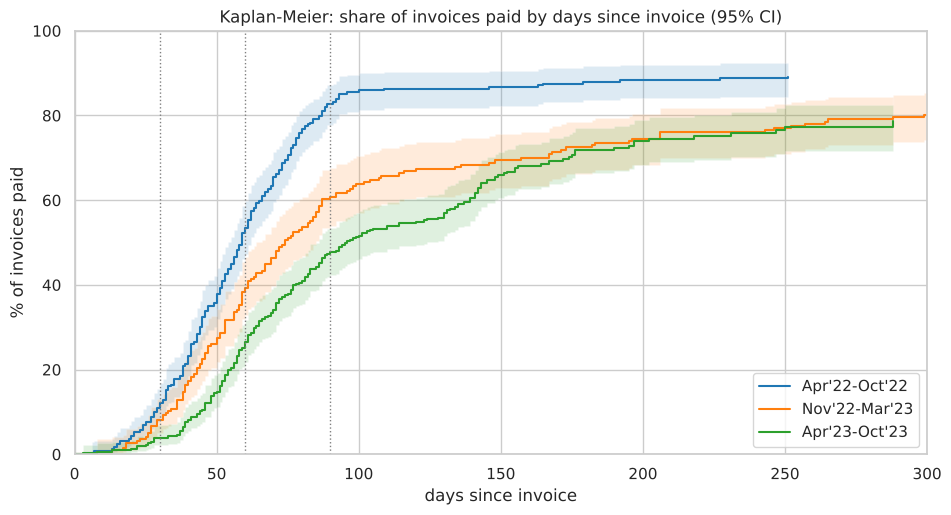

In [12]:
def kaplan_meier(duration, event):
    # product-limit estimator with Greenwood variance and log-log confidence interval
    d, e = np.asarray(duration, float), np.asarray(event, int)
    S, var, rows = 1.0, 0.0, [(0, 1.0, 1.0, 1.0)]
    for t in np.unique(d[e == 1]):
        n, k = (d >= t).sum(), ((d == t) & (e == 1)).sum()
        S *= 1 - k / n
        var += k / (n * (n - k)) if n > k else 0
        if 0 < S < 1:
            c = 1.96 * np.sqrt(var) / abs(np.log(S))
            rows.append((t, S, S ** np.exp(c), S ** np.exp(-c)))
        else:
            rows.append((t, S, S, S))
    return pd.DataFrame(rows, columns=['t', 'S', 'lo', 'hi'])

def S_at(km, t):  return km.loc[km.t <= t, 'S'].iloc[-1]
def km_median(km):
    hit = km[km.S <= 0.5]
    return hit.t.iloc[0] if len(hit) else np.inf

kms = {p: kaplan_meier(g.duration, g.event) for p, g in rep.groupby('period')}

plt.figure(figsize=(11, 5.5))
for p, km in kms.items():
    plt.step(km.t, 100 * (1 - km.S), where='post', label=PLABEL[p])
    plt.fill_between(km.t, 100 * (1 - km.hi), 100 * (1 - km.lo), step='post', alpha=0.15)
for x in (30, 60, 90):
    plt.axvline(x, color='grey', ls=':', lw=1)
plt.xlim(0, 300); plt.ylim(0, 100)
plt.xlabel('days since invoice'); plt.ylabel('% of invoices paid')
plt.title('Kaplan-Meier: share of invoices paid by days since invoice (95% CI)')
plt.legend(); plt.show()

In [13]:
stat, pval = survdiff(rep.duration.values, rep.event.values, rep.period.values)
print(f'log-rank test across the three periods: chi2 = {stat:.1f}, p = {pval:.1e}')

def dealer_bootstrap_median(g, n=500):
    # resample dealers, not invoices (invoices of the same dealer are correlated)
    ids = g.dealer_code.unique(); by = {d: x for d, x in g.groupby('dealer_code')}
    meds = [km_median(kaplan_meier(*pd.concat([by[d] for d in rng.choice(ids, len(ids))])[['duration', 'event']].values.T))
            for _ in range(n)]
    meds = np.array(meds); meds = meds[np.isfinite(meds)]
    return np.percentile(meds, [2.5, 97.5])

tbl = []
for p, km in kms.items():
    g = rep[rep.period == p]
    lo, hi = dealer_bootstrap_median(g)
    tbl.append([PLABEL[p], settled[PLABEL[p]].mean(), g.loc[g.event == 1, 'duration'].median(), km_median(km), f'{lo:.0f}-{hi:.0f}',
                1 - S_at(km, 30), 1 - S_at(km, 60), 1 - S_at(km, 90), 1 - S_at(km, 120)])
km_table = pd.DataFrame(tbl, columns=['period', '% dealers settled (Part 1)', 'median days, settled only', 'KM median days', 'KM median 95% CI',
                                      'paid by 30d', 'paid by 60d', 'paid by 90d', 'paid by 120d'])
km_table.style.format({c: '{:.0%}' for c in km_table.columns if 'paid by' in c or 'settled (' in c})

log-rank test across the three periods: chi2 = 56.7, p = 5.0e-13


,period,% dealers settled (Part 1),"median days, settled only",KM median days,KM median 95% CI,paid by 30d,paid by 60d,paid by 90d,paid by 120d
0,Apr'22-Oct'22,83%,55.000000,59.000000,47-72,12%,53%,83%,86%
1,Nov'22-Mar'23,55%,61.000000,74.000000,56-118,8%,39%,61%,67%
2,Apr'23-Oct'23,38%,72.000000,95.000000,71-149,4%,26%,48%,55%


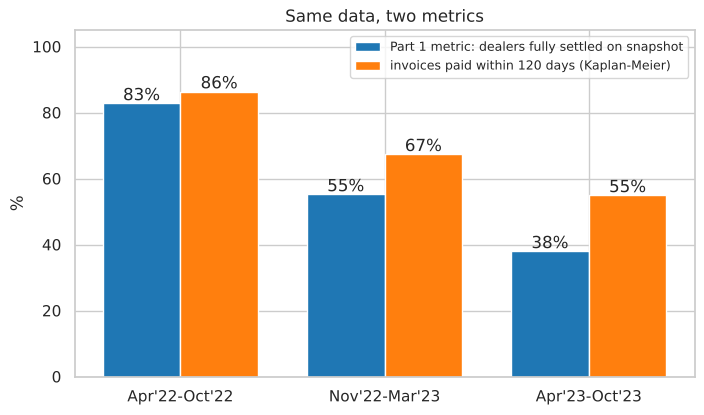

In [14]:
x = np.arange(3); w = 0.38
plt.figure(figsize=(8, 4.5))
plt.bar(x - w/2, 100 * km_table['% dealers settled (Part 1)'], w, label='Part 1 metric: dealers fully settled on snapshot')
plt.bar(x + w/2, 100 * km_table['paid by 120d'], w, label='invoices paid within 120 days (Kaplan-Meier)')
for i in range(3):
    plt.text(i - w/2, 100 * km_table['% dealers settled (Part 1)'][i] + 1, f"{km_table['% dealers settled (Part 1)'][i]:.0%}", ha='center')
    plt.text(i + w/2, 100 * km_table['paid by 120d'][i] + 1, f"{km_table['paid by 120d'][i]:.0%}", ha='center')
plt.xticks(x, km_table.period); plt.ylim(0, 105); plt.ylabel('%')
plt.legend(loc='upper right', fontsize=9); plt.title('Same data, two metrics'); plt.show()

**What this changes:**
* Payment really is getting slower (log-rank p < 0.001), not flat at 56 days as Part 1's box plot suggested. The censoring-aware median goes from **59 -> 74 -> 95 days**.
* The "collapse" from 83% to 38% is exaggerated. On a fixed 120-day horizon (which every period has had), 86% -> 67% -> 55% of invoices got paid.
* Fixed-horizon "paid within 60/90/120 days" is the metric the firm should track each month.

### 3.1 Point-in-time dealer features

For modelling I need features describing the dealer **as of the day each invoice was raised**: how fast they paid their previous invoices (only ones already settled by that day), how many invoices they have open, how old the oldest open one is, credit-limit utilisation. Using anything from after the invoice date would leak the future into the model.

In [15]:
far = SNAPSHOT + pd.Timedelta(days=10_000)
feats = []
for d, g in ledger.groupby('dealer_code'):
    dates, amt = g.invoice_date.values, g.invoice_amount.values
    pdates, days = g.receipt_date.fillna(far).values, g.days_to_pay.values
    for k, (idx, t) in enumerate(zip(g.index, dates)):
        prev = np.arange(k)
        done, open_ = prev[pdates[prev] < t], prev[pdates[prev] >= t]
        f = {'idx': idx, 'prior_n_settled': len(done), 'open_n': len(open_),
             'open_amount': amt[open_].sum() if len(open_) else 0.0,
             'max_open_age': int((t - dates[open_].min()) / np.timedelta64(1, 'D')) if len(open_) else 0,
             'days_since_last_invoice': int((t - dates[k-1]) / np.timedelta64(1, 'D')) if k else 365}
        if len(done):
            f['prior_avg_days'] = np.average(days[done], weights=amt[done])
            f['prior_share_le30'] = np.average(days[done] <= 30, weights=amt[done])
            f['prior_share_gt60'] = np.average(days[done] > 60, weights=amt[done])
        feats.append(f)

df = ledger.join(pd.DataFrame(feats).set_index('idx'))
df['no_history'] = df.prior_avg_days.isna().astype(int)
df = df.fillna({'prior_avg_days': 60, 'prior_share_le30': 0.15, 'prior_share_gt60': 0.4})
df['utilisation'] = df.open_amount / df.credit_limit
df['log_amount'] = np.log(df.invoice_amount)
df['festive'] = df.invoice_date.dt.month.isin([9, 10, 11]).astype(int)
df['tenure'] = df.invoice_date.dt.year - df.dealing_since
tv_share = items.assign(tv=lambda x: np.where(x.category == 'TV', x.qty, 0)).groupby('invoice_no').agg(tv=('tv', 'sum'), q=('qty', 'sum'))
df['tv_share'] = df.invoice_no.map(tv_share.tv / tv_share.q)
df[['invoice_no', 'dealer_name', 'invoice_date', 'prior_avg_days', 'open_n', 'max_open_age', 'utilisation', 'duration', 'event']].tail()

,invoice_no,dealer_name,invoice_date,prior_avg_days,open_n,max_open_age,utilisation,duration,event
1226,AC/01190,Agarwal Mobile & Cold Drinks,2023-12-28,64.791802,5,236,1.862667,63.0,0
1227,AC/01229,Yadav Enterprises,2023-12-29,74.424085,22,411,3.728205,62.0,0
1228,AC/01213,Mobile Expert,2023-12-30,79.025135,4,74,2.224000,60.0,1
1229,AC/01209,Marwal Mobile and Electronics,2023-12-31,73.794289,5,137,1.800000,60.0,0
1230,AC/01230,Yadav Enterprises,2023-12-31,74.424085,23,413,3.855641,60.0,0


### 3.2 Cox proportional hazards model

Kaplan-Meier shows *how fast* invoices get paid. A Cox model asks *what explains* the speed, holding other factors constant. Read each hazard ratio as "how much faster (HR > 1) or slower (HR < 1) payment happens when this factor goes up by one unit". Standard errors are clustered by dealer, since one dealer's invoices are not independent of each other.

Variables: review period, invoice size, festive season, the dealer's past average days to pay, how much of the credit limit is in use, the age of the dealer's oldest unpaid invoice, and years the dealer has traded with the firm.

In [16]:
cx = df[df.period.isin(PERIODS)].copy()
cx['P2'] = (cx.period == 'P2').astype(int); cx['P3'] = (cx.period == 'P3').astype(int)
cx['log_amount_c'] = cx.log_amount - cx.log_amount.mean()
cx['prior_avg_days_10'] = cx.prior_avg_days / 10
cx['oldest_open_30'] = cx.max_open_age / 30
cox_vars = ['P2', 'P3', 'log_amount_c', 'festive', 'prior_avg_days_10', 'utilisation', 'oldest_open_30', 'tenure']

cox = PHReg(cx.duration.values, cx[cox_vars].astype(float).values, status=cx.event.values, ties='efron').fit(groups=cx.dealer_code.values)
ci = np.exp(cox.conf_int())
cox_tbl = pd.DataFrame({'hazard_ratio': np.exp(cox.params), 'ci_low': ci[:, 0], 'ci_high': ci[:, 1], 'p_value': cox.pvalues}, index=cox_vars)
cox_tbl.round(3)

,hazard_ratio,ci_low,ci_high,p_value
P2,0.456,0.237,0.877,0.019
P3,0.647,0.376,1.111,0.114
log_amount_c,1.124,1.003,1.260,0.044
festive,1.111,0.875,1.409,0.388
prior_avg_days_10,0.902,0.796,1.021,0.103
utilisation,1.153,0.743,1.791,0.525
oldest_open_30,0.653,0.563,0.758,0.000
tenure,1.072,1.002,1.147,0.045


Harrell C-index: 0.793
{'P2': np.float64(0.0), 'P3': np.float64(0.0), 'log_amount_c': np.float64(0.0), 'festive': np.float64(0.89), 'prior_avg_days_10': np.float64(0.0), 'utilisation': np.float64(0.0), 'oldest_open_30': np.float64(0.0), 'tenure': np.float64(0.809)}


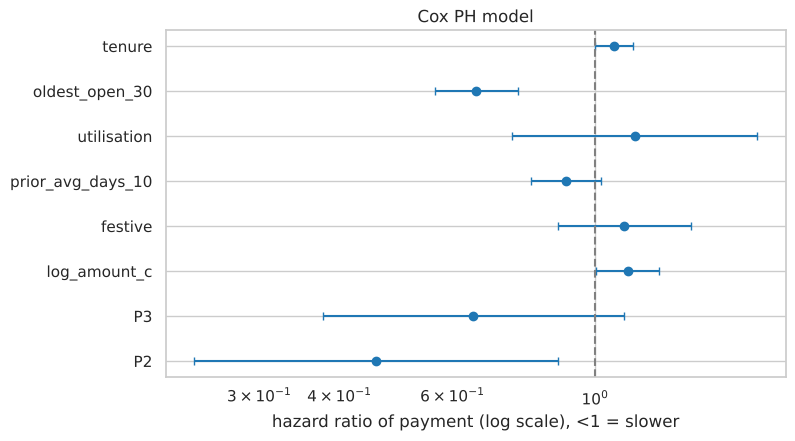

In [17]:
def concordance(duration, event, risk):
    d, e, r = map(np.asarray, (duration, event, risk)); num = den = 0.0
    for i in np.where(e == 1)[0]:
        comp = d > d[i]; den += comp.sum()
        num += (r[i] > r[comp]).sum() + 0.5 * (r[i] == r[comp]).sum()
    return num / den

print('Harrell C-index:', round(concordance(cx.duration, cx.event, cx[cox_vars].values @ cox.params), 3))

# proportional-hazards check: Schoenfeld residuals vs rank of time
sr = cox.schoenfeld_residuals; ev = cx.event.values == 1
t_rank = stats.rankdata(cx.duration.values[ev])
print({v: round(stats.pearsonr(t_rank, sr[ev, j])[1], 3) for j, v in enumerate(cox_vars)})

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(cox_tbl))
ax.errorbar(cox_tbl.hazard_ratio, y, xerr=[cox_tbl.hazard_ratio - cox_tbl.ci_low, cox_tbl.ci_high - cox_tbl.hazard_ratio],
            fmt='o', capsize=3)
ax.axvline(1, color='grey', ls='--'); ax.set_xscale('log')
ax.set_yticks(y, cox_tbl.index); ax.set_xlabel('hazard ratio of payment (log scale), <1 = slower')
ax.set_title('Cox PH model'); plt.show()

* **Oldest open invoice** is the strongest signal: every extra 30 days on a dealer's oldest unpaid bill cuts the payment hazard by about a third (HR ~0.65).
* Once that's controlled for, the Apr'23-Oct'23 period effect isn't significant any more (p ~ 0.1). So it's not that *everyone* got slower; dealers who were already behind kept falling further behind.
* The PH assumption is violated for several variables (small p-values above), so I read these as average effects and use a separate classifier for prediction.

**Within-dealer check.** Odd result above: bigger invoices seem to get paid slightly *faster* (HR > 1). That's because big invoices mostly come from big dealers, who pay faster. A dealer x period fixed-effects regression on settled invoices compares invoices of the same dealer instead:

In [18]:
fe = cx[cx.event == 1].copy()
fe['oct_nov'] = fe.invoice_date.dt.month.isin([10, 11]).astype(int)
grp = fe.dealer_code + fe.period
y_ = fe.duration - fe.groupby(grp).duration.transform('mean')
X_ = fe[['log_amount', 'oct_nov']] - fe.groupby(grp)[['log_amount', 'oct_nov']].transform('mean')
fe_model = sm.OLS(y_, X_).fit(cov_type='cluster', cov_kwds={'groups': fe.dealer_code})
print(fe_model.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
log_amount     3.8349      1.241      3.091      0.002       1.403       6.266
oct_nov       -5.5062      1.969     -2.797      0.005      -9.364      -1.648


Within the same dealer and period it flips: a bigger invoice takes ~5 more days per log-unit (about x2.7 in size), and stock bought for Oct-Nov is cleared and paid ~4-5 days faster. Comparing across dealers gave the wrong sign, a nice example of Simpson's paradox.

## 4. Late-payment risk model

**Target:** invoice not paid within 60 days (slips past credit cycle 2). I only keep invoices that have been out for more than 60 days, so the label is known for all of them.

**Split by time, not randomly:** train on invoices raised before 2023, test on 2023. That's how the model would actually be used, and it's harder than a random split because behaviour got worse in 2023.

Three candidates: a **logistic regression** (simple, explainable, can be turned into points), **gradient-boosted trees** (more flexible, with monotonic constraints so that, for example, an older unpaid bill can never *lower* the risk), and a **baseline** that only looks at the dealer's past share of late payments.

In [19]:
m = df[df.days_open > 60].copy()
m['late60'] = (m.duration > 60).astype(int)
train, test = m[m.invoice_date < '2023-01-01'], m[m.invoice_date >= '2023-01-01']
print(f'train {len(train)} invoices, {train.late60.mean():.0%} late | test {len(test)} invoices, {test.late60.mean():.0%} late')

all_feats = ['prior_avg_days', 'prior_share_le30', 'prior_share_gt60', 'prior_n_settled', 'no_history', 'open_n',
             'utilisation', 'max_open_age', 'days_since_last_invoice', 'log_amount', 'tv_share', 'festive', 'tenure']
# scorecard uses a smaller set: open_n / utilisation overlap with max_open_age and flip sign in a linear model
card_feats = ['prior_avg_days', 'prior_share_le30', 'prior_share_gt60', 'no_history', 'max_open_age', 'log_amount', 'festive', 'tenure']
monotone = {'prior_avg_days': 1, 'prior_share_le30': -1, 'prior_share_gt60': 1, 'max_open_age': 1, 'utilisation': 1, 'open_n': 1}

logit = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=2000)).fit(train[card_feats], train.late60)
gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=250, l2_regularization=1.0, min_samples_leaf=20,
                                     monotonic_cst=[monotone.get(f, 0) for f in all_feats], random_state=SEED).fit(train[all_feats], train.late60)

preds = {'Logistic scorecard': logit.predict_proba(test[card_feats])[:, 1],
         'Gradient boosting': gbm.predict_proba(test[all_feats])[:, 1],
         'Baseline: past share paid >60d': test.prior_share_gt60.values}
pd.DataFrame([{'model': k, 'ROC-AUC': roc_auc_score(test.late60, p), 'PR-AUC': average_precision_score(test.late60, p),
               'Brier': brier_score_loss(test.late60, p) if 'Baseline' not in k else np.nan} for k, p in preds.items()]).round(3)

train 719 invoices, 48% late | test 510 invoices, 71% late


,model,ROC-AUC,PR-AUC,Brier
0,Logistic scorecard,0.833,0.919,0.160
1,Gradient boosting,0.770,0.872,0.232
2,Baseline: past share paid >60d,0.713,0.849,NaN


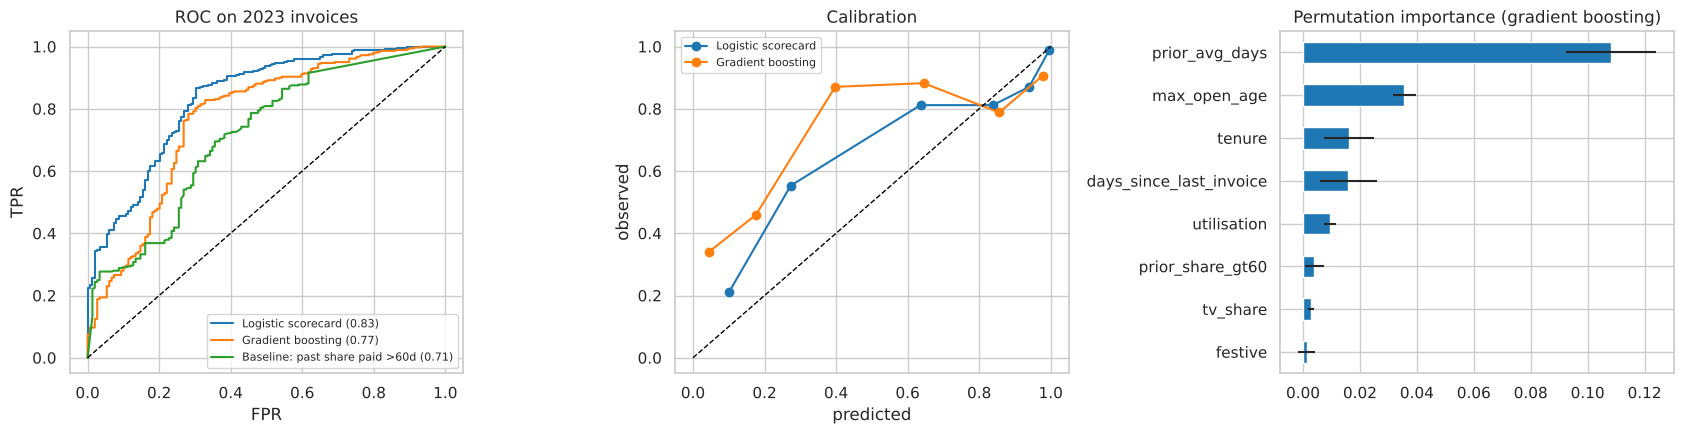

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for k, p in preds.items():
    fpr, tpr, _ = roc_curve(test.late60, p)
    axes[0].plot(fpr, tpr, label=f'{k} ({roc_auc_score(test.late60, p):.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1); axes[0].set_title('ROC on 2023 invoices'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

for k in list(preds)[:2]:
    fr, mp = calibration_curve(test.late60, preds[k], n_bins=6, strategy='quantile')
    axes[1].plot(mp, fr, marker='o', label=k)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1); axes[1].set_title('Calibration'); axes[1].legend(fontsize=8)
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('observed')

pi = permutation_importance(gbm, test[all_feats], test.late60, scoring='roc_auc', n_repeats=30, random_state=SEED)
imp = pd.Series(pi.importances_mean, all_feats).sort_values()
imp.tail(8).plot(kind='barh', ax=axes[2], xerr=pd.Series(pi.importances_std, all_feats)[imp.tail(8).index])
axes[2].set_title('Permutation importance (gradient boosting)')
plt.tight_layout(); plt.show()

The plain logistic model beats gradient boosting out of time (AUC ~0.83 vs ~0.77), which makes sense with ~700 training rows. Both beat the "just look at their history" baseline. Calibration is off because lateness jumped from 48% to 71% between train and test; ranking still holds, so in practice I'd re-fit the intercept every quarter.

### 4.1 How does Part 1's model compare?

Part 1's model looked good (ROC-AUC ~0.80), but it had two problems: each dealer's average days to pay was computed over the **whole** period, including payments made *after* the invoice being predicted, and the train/test split was random, so the model trained on 2023 invoices and tested on 2022 ones. Below I re-score it three ways.

In [21]:
from sklearn.model_selection import train_test_split
p1 = m.merge(ledger.groupby('dealer_code').agg(dealer_avg_days=('days_to_pay', 'mean'),
                                               dealer_share_30=('days_to_pay', lambda d: (d <= 30).mean())),
             left_on='dealer_code', right_index=True, how='left')
p1['dealer_avg_days'] = p1.dealer_avg_days.fillna(p1.dealer_avg_days.max())
p1_feats = ['dealer_avg_days', 'dealer_share_30', 'log_amount', 'festive', 'tenure']
simple_logit = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# a) as built in Part 1: whole-period dealer averages, random 75/25 split
Xa, Xb, ya, yb = train_test_split(p1[p1_feats], p1.late60, test_size=0.25, random_state=SEED, stratify=p1.late60)
auc_a = roc_auc_score(yb, simple_logit().fit(Xa, ya).predict_proba(Xb)[:, 1])
# b) same features, but trained before 2023 and tested on 2023 (features still leak)
tr1, te1 = p1[p1.invoice_date < '2023-01-01'], p1[p1.invoice_date >= '2023-01-01']
auc_b = roc_auc_score(te1.late60, simple_logit().fit(tr1[p1_feats], tr1.late60).predict_proba(te1[p1_feats])[:, 1])
# c) same idea with point-in-time features: only payments settled before the invoice date count
pit = ['prior_avg_days', 'prior_share_le30', 'log_amount', 'festive', 'tenure']
auc_c = roc_auc_score(test.late60, simple_logit().fit(train[pit], train.late60).predict_proba(test[pit])[:, 1])

pd.DataFrame({'ROC-AUC': [auc_a, auc_b, auc_c, roc_auc_score(test.late60, preds['Logistic scorecard'])]},
             index=['Part 1 model as built (leaky features, random split)',
                    'Part 1 features, tested on 2023 (still leaky)',
                    'Part 1 features made point-in-time, tested on 2023 (honest)',
                    'Part 2 scorecard, tested on 2023 (honest)']).round(3)

,ROC-AUC
"Part 1 model as built (leaky features, random split)",0.799
"Part 1 features, tested on 2023 (still leaky)",0.834
"Part 1 features made point-in-time, tested on 2023 (honest)",0.744
"Part 2 scorecard, tested on 2023 (honest)",0.833


* As built, Part 1's model scores about **0.80**.
* Trained on 2021-22 and tested on 2023 with the same leaky features, it scores even higher (~0.83). That isn't a good sign: the dealer averages already include how each dealer paid in 2023, so the model is partly reading the answer.
* Using only what was known on each invoice date, the same feature set drops to about **0.74**. That's the honest version of Part 1's model.
* Part 2's scorecard reaches ~0.83 honestly, mainly by adding the **age of the dealer's oldest unpaid bill** and the share of past invoices paid after 60 days.

Leakage like this is easy to miss because it makes a model look better, not worse.

### 4.2 Turning the logistic model into a credit scorecard

Standard credit-scoring scaling: 600 points = even odds of paying within 60 days, and every +20 points doubles the odds.

In [22]:
PDO, BASE, BASE_ODDS = 20, 600, 1.0
factor = PDO / np.log(2); offset = BASE - factor * np.log(BASE_ODDS)
lr, sc = logit.named_steps['logisticregression'], logit.named_steps['standardscaler']
print(pd.Series(-factor * lr.coef_[0], card_feats).sort_values().round(1).rename('points per +1 std dev'))

# score every dealer for a new median-size invoice raised on 1-Jan-2024, using only what was known that day
asof = pd.Timestamp('2024-01-01')
rows = []
for d, g in ledger[ledger.invoice_date < asof].groupby('dealer_code'):
    done = g[g.receipt_date < asof]; open_ = g[~(g.receipt_date < asof)]
    w = done.invoice_amount
    rows.append({'dealer_code': d, 'dealer_name': g.dealer_name.iloc[0],
                 'prior_avg_days': np.average(done.days_to_pay, weights=w) if len(done) else 60,
                 'prior_share_le30': np.average(done.days_to_pay <= 30, weights=w) if len(done) else 0.15,
                 'prior_share_gt60': np.average(done.days_to_pay > 60, weights=w) if len(done) else 0.4,
                 'no_history': int(len(done) == 0), 'max_open_age': (asof - open_.invoice_date.min()).days if len(open_) else 0,
                 'log_amount': np.log(ledger.invoice_amount.median()), 'festive': 0, 'tenure': 2024 - g.dealing_since.iloc[0],
                 'open_amount_lakh': open_.invoice_amount.sum() / 1e5})
scores = pd.DataFrame(rows)
scores['p_late60'] = logit.predict_proba(scores[card_feats])[:, 1]
scores['score'] = (offset + factor * np.log((1 - scores.p_late60) / scores.p_late60)).round().astype(int)
scores['band'] = pd.cut(scores.score, [-1e9, 480, 570, 620, 1e9], labels=['D hold', 'C watch', 'B standard', 'A preferred'])
scores.sort_values('score')[['dealer_name', 'score', 'band', 'p_late60', 'max_open_age', 'prior_avg_days', 'open_amount_lakh']].round(2)

prior_avg_days     -48.2
prior_share_gt60   -19.1
prior_share_le30   -18.8
log_amount         -13.8
max_open_age       -13.1
no_history          -7.0
tenure               5.3
festive              9.1
Name: points per +1 std dev, dtype: float64


,dealer_name,score,band,p_late60,max_open_age,prior_avg_days,open_amount_lakh
19,Radhika Air & Vision,223,D hold,1.00,626,117.79,5.04
23,Shri Govindam Electronics and Appliances,244,D hold,1.00,631,109.32,6.17
10,Jai Shree Shyam,255,D hold,1.00,611,108.65,5.21
20,Riddhi Siddhi Enterprises,269,D hold,1.00,622,98.09,5.27
5,Deepanshi Electronics,277,D hold,1.00,588,101.56,5.09
1,Anuj Marketing,353,D hold,1.00,373,101.84,3.98
27,Yadav Enterprises,387,D hold,1.00,414,86.66,14.44
9,Hitesh Communication,424,D hold,1.00,330,89.70,4.57
8,Goyal Electronics,429,D hold,1.00,424,77.96,6.16
26,Techno Tree,441,D hold,1.00,365,70.88,5.42


## 5. Dealer segmentation

Part 1 clustered dealers on average days, 30-day share and periods cleared. Here I use four features measured as shares of billed value, which weights dealers by money at risk rather than invoice counts, and pick k with the silhouette score. These segments feed the policy simulation in section 6.

In [23]:
seg_rows = []
for (d, n), g in rep.groupby(['dealer_code', 'dealer_name']):
    p_, billed = g[g.event == 1], g.invoice_amount.sum()
    seg_rows.append({'dealer_code': d, 'dealer_name': n, 'billed': billed,
                     'avg_days': np.average(p_.duration, weights=p_.invoice_amount) if len(p_) else np.nan,
                     'share_le30': g.loc[(g.event == 1) & (g.duration <= 30), 'invoice_amount'].sum() / billed,
                     'share_gt60': g.loc[g.duration > 60, 'invoice_amount'].sum() / billed,
                     'open_share': g.loc[g.event == 0, 'invoice_amount'].sum() / billed})
seg = pd.DataFrame(seg_rows)
seg['avg_days'] = seg.avg_days.fillna(seg.avg_days.max())
X = StandardScaler().fit_transform(seg[['avg_days', 'share_le30', 'share_gt60', 'open_share']])

sil = {k: silhouette_score(X, KMeans(k, n_init=50, random_state=SEED).fit_predict(X)) for k in range(2, 7)}
print({k: round(v, 3) for k, v in sil.items()})

{2: 0.432, 3: 0.456, 4: 0.495, 5: 0.442, 6: 0.467}


k=2 just separates payers from non-payers (the heatmap already does that); among k>=3 the silhouette is highest at k=4.

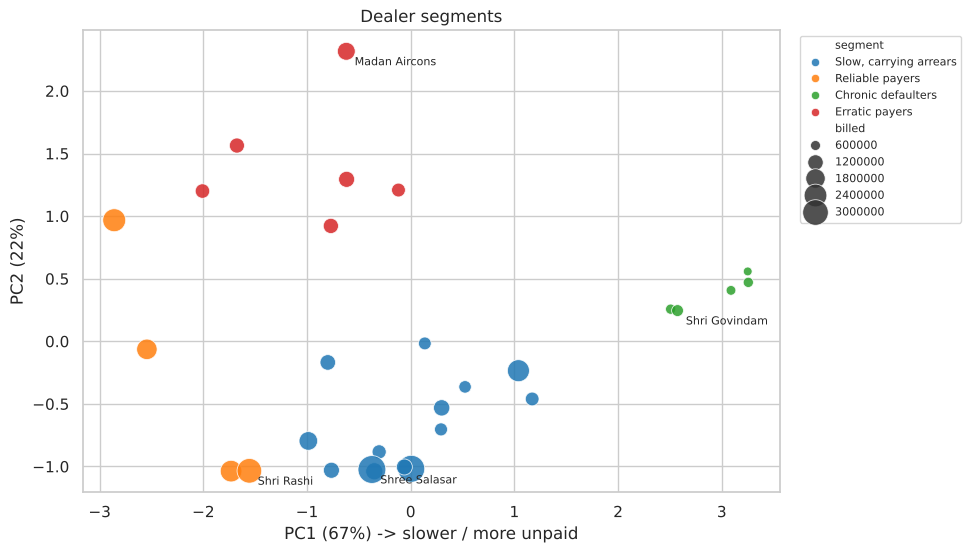

,dealers,billed_lakh,avg_days,paid_in_30d,later_than_60d,still_open
segment,,,,,,
Chronic defaulters,5,31.06,196.15,0.00,1.00,0.77
Erratic payers,6,72.25,77.63,0.23,0.62,0.20
Reliable payers,4,93.91,47.05,0.08,0.11,0.00
"Slow, carrying arrears",14,219.13,90.93,0.01,0.74,0.15


In [24]:
k = max((kk for kk in sil if kk >= 3), key=sil.get)
seg['cluster'] = KMeans(k, n_init=50, random_state=SEED).fit_predict(X)
prof = seg.groupby('cluster')[['avg_days', 'share_le30', 'share_gt60', 'open_share']].mean()

def name(c):
    if c.open_share > 0.40: return 'Chronic defaulters'
    if c.open_share > 0.08 and c.share_le30 > 0.15: return 'Erratic payers'
    if c.open_share > 0.08: return 'Slow, carrying arrears'
    if c.share_gt60 > 0.45: return 'Slow but paying'
    return 'Reliable payers'
seg['segment'] = seg.cluster.map({c: name(prof.loc[c]) for c in prof.index})

pcs = PCA(2, random_state=SEED).fit(X); xy = pcs.transform(X)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=seg.segment, size=seg.billed, sizes=(40, 400), alpha=0.85)
for i in seg.groupby('segment').billed.idxmax():
    plt.annotate(' '.join(seg.dealer_name[i].split()[:2]), xy[i], xytext=(6, -10), textcoords='offset points', fontsize=8)
plt.xlabel(f'PC1 ({pcs.explained_variance_ratio_[0]:.0%}) -> slower / more unpaid'); plt.ylabel(f'PC2 ({pcs.explained_variance_ratio_[1]:.0%})')
plt.title('Dealer segments'); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8); plt.show()

seg_profile = seg.groupby('segment').agg(dealers=('dealer_code', 'size'), billed_lakh=('billed', lambda s: s.sum() / 1e5),
                                         avg_days=('avg_days', 'mean'), paid_in_30d=('share_le30', 'mean'),
                                         later_than_60d=('share_gt60', 'mean'), still_open=('open_share', 'mean'))
seg_profile.round(2)

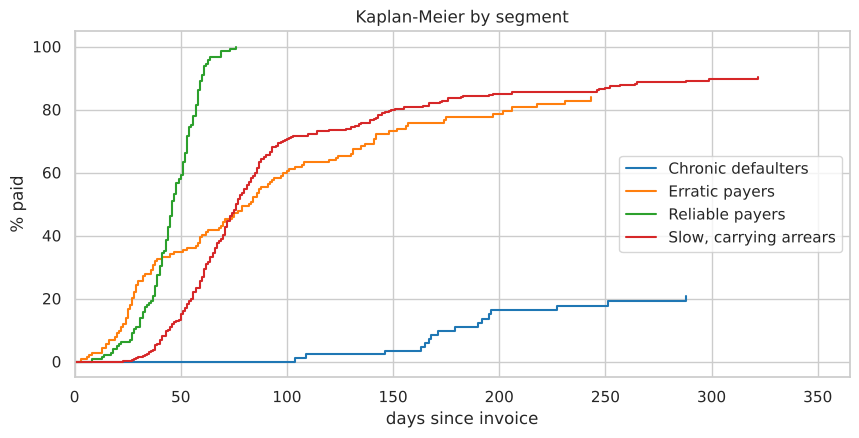

In [25]:
seg_of = seg.set_index('dealer_code').segment
plt.figure(figsize=(10, 4.5))
for s, g in rep.assign(segment=rep.dealer_code.map(seg_of)).groupby('segment'):
    km = kaplan_meier(g.duration, g.event)
    plt.step(km.t, 100 * (1 - km.S), where='post', label=s)
plt.xlim(0, 365); plt.xlabel('days since invoice'); plt.ylabel('% paid'); plt.legend(); plt.title('Kaplan-Meier by segment'); plt.show()

| Segment | Suggested terms |
|---|---|
| Reliable payers | Higher limit; the only group where an early-payment incentive could make sense |
| Erratic / slow, carrying arrears | Freeze limit at current exposure; no new dispatch while anything is >60 days open |
| Chronic defaulters | Advance payment only until dues are cleared; recovery action past 180 days |

## 6. Is the 3% discount + 9% penalty actually a good idea?

Part 1 recommended a 3% discount for paying within 30 days and a 9% penalty after that, without costing either. Quick sanity check first: a discount is only worth it if it costs less than financing the receivable for the days it saves,

$$d < r \cdot \frac{T - w}{365}$$

With money at ~11.5% (bank cash-credit rate, my assumption) and paying invoices settling after ~92 days on average, the break-even discount for 30-day payment is about 2%, so 3% is already too much. And that ignores dealers who would pay early anyway and just pocket the discount.

To compare policies properly I simulate the 2023 invoice book 1,000 times per policy:
* each invoice's baseline days-to-pay is drawn from its segment's Kaplan-Meier curve (mass never reached in follow-up is either written off or paid very late);
* a dealer pays early only if the discount/avoided penalty beats **its own** cost of money (retailers borrow at ~14-26%) for the days it gives up, and only if it has the cash (segment-dependent);
* firm cost of funds, recovery on bad debt, how much of a penalty actually gets collected, and the chance a penalised dealer stops stocking Sansui are all redrawn every run.

In [26]:
GM = products.set_index('model_code').distributor_margin_pct / 100
inv_margin = (items.assign(m=items.amount * items.model_code.map(GM)).groupby('invoice_no')[['m', 'amount']].sum().pipe(lambda x: x.m / x.amount))

ABILITY = {'Reliable payers': 0.9, 'Slow but paying': 0.6, 'Erratic payers': 0.5, 'Slow, carrying arrears': 0.35, 'Chronic defaulters': 0.05}
TAIL_WRITE_OFF = {'Chronic defaulters': 0.9}   # share of never-paid-in-follow-up that is eventually written off (else 0.5)
seg_cdf = {}
for s, g in rep.assign(segment=rep.dealer_code.map(seg_of)).groupby('segment'):
    km = kaplan_meier(g.duration, g.event); seg_cdf[s] = (km.t.values, 1 - km.S.values)

def draw_days(s, n, rng):
    t, F = seg_cdf[s]; u = rng.random(n); idx = np.searchsorted(F, u)
    tail = idx >= len(F); T = t[np.minimum(idx, len(t) - 1)].astype(float)
    write_off = rng.random(n) < TAIL_WRITE_OFF.get(s, 0.5)
    return np.where(tail, np.where(write_off, np.inf, t[-1] + rng.uniform(0, 180, n)), T)

book = ledger[ledger.invoice_date.dt.year == 2023].copy()
book['segment'] = book.dealer_code.map(seg_of); book['g'] = book.invoice_no.map(inv_margin)
A, g, segs = book.invoice_amount.values, book.g.values, book.segment.values
dlr, dlr_idx = np.unique(book.dealer_code.values, return_inverse=True)
annual_margin = np.bincount(dlr_idx, weights=A * g)

def simulate(disc=0.0, window=0, flat_pen=0.0, int_m=0.0, grace=0, hold=False, n_sims=1000, dealer_rate=(0.14, 0.26), seed=SEED):
    rng = np.random.default_rng(seed)   # same seed for every policy = common random numbers, so policies are compared on identical scenarios
    res = []
    held = (segs == 'Chronic defaulters') if hold else np.zeros(len(A), bool)
    for _ in range(n_sims):
        r_f, rec, enforce, churn_k = rng.uniform(0.10, 0.13), rng.uniform(0.2, 0.5), rng.uniform(0.3, 0.7), rng.uniform(0.5, 2.0)
        r_d = rng.uniform(*dealer_rate, len(dlr))[dlr_idx]
        able = rng.random(len(A)) < np.clip([ABILITY[s] + rng.normal(0, 0.08) for s in segs], 0, 1)
        T0 = np.empty(len(A))
        for s in np.unique(segs):
            T0[segs == s] = draw_days(s, (segs == s).sum(), rng)
        default = ~np.isfinite(T0); T0f = np.where(default, 0, T0)

        def pen(t):  return flat_pen * (t > 30) + int_m * np.maximum(t - grace, 0) / 30
        def dealer_cost(t):  return -r_d * t / 365 - disc * (t <= window) + enforce * pen(t)
        T, best = T0f.copy(), dealer_cost(T0f)
        for c in {window, 30 if flat_pen else 0, grace if int_m else 0} - {0}:
            cost = dealer_cost(np.full(len(A), float(c)))
            take = able & (c < T0f) & (cost < best) & ~default
            T, best = np.where(take, c, T), np.where(take, cost, best)

        d_paid = disc * ((T <= window) & ~default)
        p_coll = np.where(default, 0, pen(T) * enforce)
        val = np.where(default, -(1 - g) * (1 - rec) - r_f * (1 - g), g - r_f * T / 365 * (1 - g) - d_paid + p_coll)
        val = np.where(held, 0, val)
        penalised = np.bincount(dlr_idx, weights=((pen(T) > 0) & ~default & ~held).astype(float)) > 0
        churn = (np.minimum(0.6, churn_k * (flat_pen or 2 * int_m)) * penalised * annual_margin).sum()
        live = ~held; ok = live & ~default
        res.append({'net_per_100': 100 * ((A * val)[live].sum() - churn) / A.sum(),
                    'dso': np.average(T[ok], weights=A[ok]),
                    'bad_debt_%': 100 * A[live & default].sum() / A[live].sum(),
                    'discount_cost': 100 * (A * d_paid)[live].sum() / A.sum(),
                    'discount_to_early_payers_anyway': 100 * (A * d_paid * (T0f <= window))[live].sum() / A.sum(),
                    'penalty_collected': 100 * (A * p_coll)[live].sum() / A.sum(),
                    'churn_loss': 100 * churn / A.sum()})
    return pd.DataFrame(res)

policies = {
    'Status quo (net 30, nothing enforced)': {},
    'Part 1: 3% <=30d + 9% penalty':          dict(disc=0.03, window=30, flat_pen=0.09),
    'Only the 3% discount':                   dict(disc=0.03, window=30),
    '1% if paid within 10 days':              dict(disc=0.01, window=10),
    '18% p.a. interest after 45 days':        dict(int_m=0.015, grace=45),
    'Credit hold for chronic defaulters':     dict(hold=True),
    'Interest after 45d + credit hold':       dict(int_m=0.015, grace=45, hold=True),
}
sims = {k: simulate(**v) for k, v in policies.items()}   # takes ~1 min
base = sims['Status quo (net 30, nothing enforced)'].net_per_100.values
summary = pd.DataFrame({k: {**s.mean().to_dict(), 'p5': s.net_per_100.quantile(.05), 'p95': s.net_per_100.quantile(.95),
                            'P(beats status quo)': (s.net_per_100.values > base).mean()} for k, s in sims.items()}).T
summary.round(2)

,net_per_100,dso,bad_debt_%,discount_cost,discount_to_early_payers_anyway,penalty_collected,churn_loss,p5,p95,P(beats status quo)
"Status quo (net 30, nothing enforced)",-2.00,91.68,7.74,0.00,0.00,0.00,0.00,-3.84,-0.38,0.00
Part 1: 3% <=30d + 9% penalty,-1.67,77.73,7.74,1.39,0.24,2.05,0.71,-3.78,0.19,0.73
Only the 3% discount,-2.98,83.23,7.74,1.21,0.24,0.00,0.00,-4.82,-1.39,0.00
1% if paid within 10 days,-2.03,91.13,7.74,0.05,0.01,0.00,0.00,-3.87,-0.41,0.00
18% p.a. interest after 45 days,-1.11,91.68,7.74,0.00,0.00,1.14,0.24,-3.06,0.61,1.00
Credit hold for chronic defaulters,0.67,89.26,4.24,0.00,0.00,0.00,0.00,-0.79,1.96,1.00
Interest after 45d + credit hold,1.50,89.26,4.24,0.00,0.00,1.06,0.23,-0.10,2.85,1.00


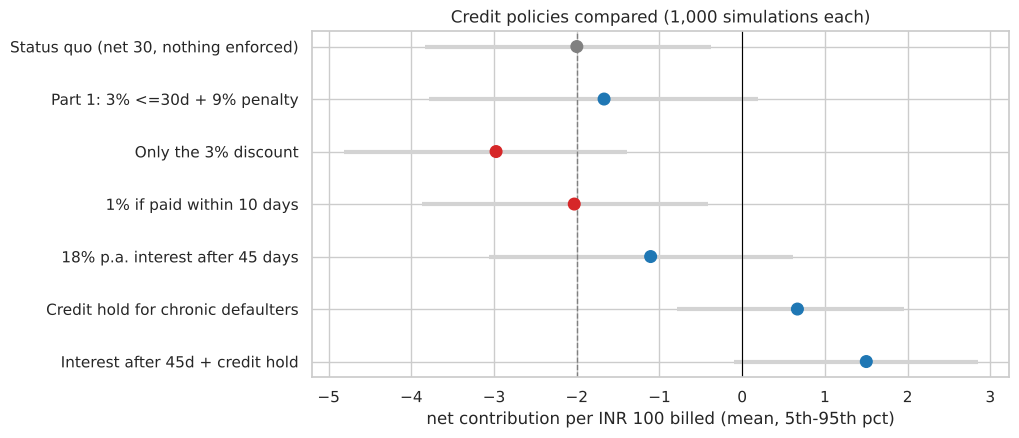

In [27]:
s_ = summary.iloc[::-1]
plt.figure(figsize=(9, 4.5))
colors = ['grey' if 'Status quo' in i else ('tab:blue' if v > summary.net_per_100.iloc[0] else 'tab:red') for i, v in s_.net_per_100.items()]
plt.errorbar(s_.net_per_100, range(len(s_)), xerr=[s_.net_per_100 - s_.p5, s_.p95 - s_.net_per_100], fmt='none', ecolor='lightgrey', lw=3)
plt.scatter(s_.net_per_100, range(len(s_)), c=colors, s=70, zorder=3)
plt.axvline(summary.net_per_100.iloc[0], color='grey', ls='--', lw=1); plt.axvline(0, color='black', lw=0.8)
plt.yticks(range(len(s_)), s_.index); plt.xlabel('net contribution per INR 100 billed (mean, 5th-95th pct)')
plt.title('Credit policies compared (1,000 simulations each)'); plt.show()

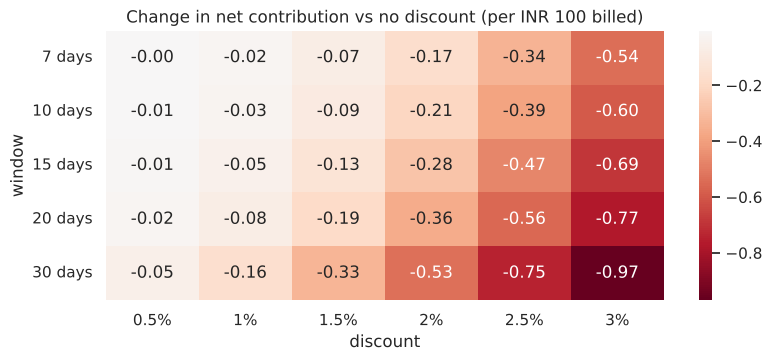

In [28]:
# how big should a discount be, and for how many days? (fewer sims per cell to keep it quick)
grid = {}
for w in [7, 10, 15, 20, 30]:
    base_w = simulate(n_sims=150).net_per_100.mean()
    grid[f'{w} days'] = {f'{d}%': simulate(disc=d / 100, window=w, n_sims=150).net_per_100.mean() - base_w for d in [0.5, 1, 1.5, 2, 2.5, 3]}
grid = pd.DataFrame(grid).T
plt.figure(figsize=(9, 3.5))
sns.heatmap(grid, annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Change in net contribution vs no discount (per INR 100 billed)'); plt.xlabel('discount'); plt.ylabel('window'); plt.show()

**Result:** no discount size or window adds value under these assumptions. The 3% discount on its own is the worst option. Part 1's combined discount-plus-penalty proposal only looks slightly better than doing nothing because the 9% penalty brings in money, and that's offset by dealers it would drive away.

What works is boring: **charge interest on overdue bills after 45 days and stop supplying the five chronic defaulters until they clear dues**. Each of these beats the status quo in every simulation run on its own, and together they're the best option by a distance (about +1.5 vs -2.0 per INR 100 billed). Credit hold gives up ~5% of sales, but those are sales that mostly never got paid for.

The reason discounts fail: retailers borrow at 14-26%, the distributor at ~11.5%. The distributor is the cheaper lender, so it costs more to bribe dealers to pay early than it costs to just finance the receivable.

## 7. Demand: which models are really trending?

Part 1 labelled models growing, fluctuating or declining from three yearly totals (nine of twelve TVs came out as growing) and recommended shifting stock investment towards growing models. Here each model is a 36-month sales series built from the invoice items, and trends are tested statistically.

In [29]:
Y = items.pivot_table(index='month', columns='model_code', values='qty', aggfunc='sum').fillna(0).sort_index()
Y = Y.reindex(pd.date_range(Y.index.min(), '2023-12-01', freq='MS'), fill_value=0); Y.index.freq = 'MS'
yearly = Y.groupby(Y.index.year).sum().T
yearly.columns = ['2021', '2022', '2023']
yearly

,2021,2022,2023
model_code,,,
TV-JJSW55ASUHD,88.0,215.0,237.0
TV-JSP90S-2022N,75.0,50.0,117.0
TV-JST32SKHD,23.0,130.0,190.0
TV-JSW32ASHD,49.0,80.0,209.0
TV-JSW32NSHD,76.0,100.0,193.0
TV-JSW40ASFHD,45.0,165.0,211.0
TV-JSW43ASFHD,35.0,45.0,172.0
TV-JSY24NSHD,56.0,180.0,182.0
TV-JSY24NSHD-A,68.0,210.0,205.0


The problem with that: the whole business tripled between 2021 and 2023, so almost every TV's unit sales went up regardless of how the model itself was doing. Rising units can't identify winners.

So I test the trend in each model's **share of its category** with Mann-Kendall (Kendall's tau against time) on the 36 monthly points.

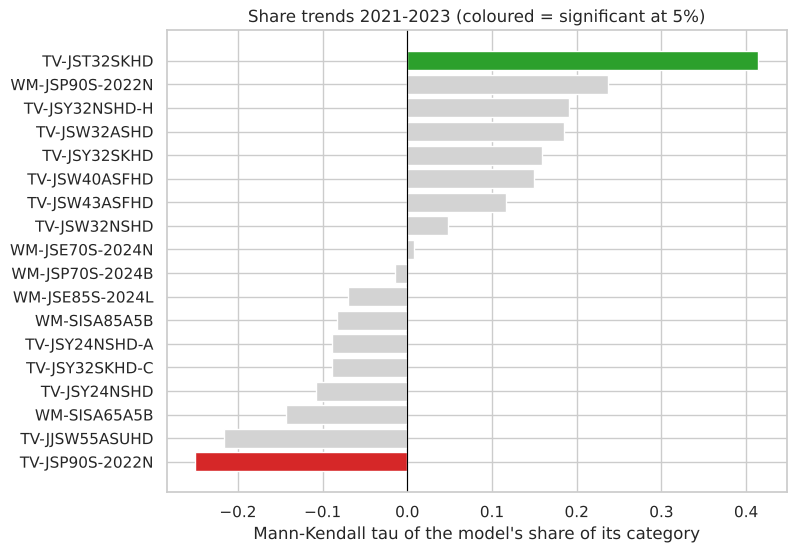

,tau_units,p_units,tau_share,p_share,verdict
model,,,,,
TV-JJSW55ASUHD,0.572,0.000,-0.216,0.064,no significant change
TV-JSP90S-2022N,0.379,0.002,-0.251,0.031,losing share
TV-JST32SKHD,0.740,0.000,0.415,0.000,gaining share
TV-JSW32ASHD,0.644,0.000,0.184,0.114,no significant change
TV-JSW32NSHD,0.635,0.000,0.048,0.683,no significant change
TV-JSW40ASFHD,0.567,0.000,0.149,0.200,no significant change
TV-JSW43ASFHD,0.504,0.000,0.116,0.320,no significant change
TV-JSY24NSHD,0.540,0.000,-0.108,0.354,no significant change
TV-JSY24NSHD-A,0.503,0.000,-0.089,0.446,no significant change


In [30]:
cat_total = {c: Y[[s for s in Y if s.startswith(c)]].sum(axis=1) for c in ('TV', 'WM')}
t = np.arange(len(Y))
trend = []
for s in Y:
    share = (Y[s] / cat_total[s[:2]].replace(0, np.nan)).fillna(0)
    tau_u, p_u = stats.kendalltau(t, Y[s]); tau_s, p_s = stats.kendalltau(t, share)
    trend.append({'model': s, 'tau_units': tau_u, 'p_units': p_u, 'tau_share': tau_s, 'p_share': p_s,
                  'verdict': ('gaining share' if tau_s > 0 else 'losing share') if p_s < 0.05 else 'no significant change'})
trend = pd.DataFrame(trend).set_index('model')

tr = trend.sort_values('tau_share')
plt.figure(figsize=(8, 6))
plt.barh(tr.index, tr.tau_share, color=tr.verdict.map({'gaining share': 'tab:green', 'losing share': 'tab:red', 'no significant change': 'lightgrey'}))
plt.axvline(0, color='black', lw=0.8); plt.xlabel("Mann-Kendall tau of the model's share of its category")
plt.title('Share trends 2021-2023 (coloured = significant at 5%)'); plt.show()
trend.round(3)

Only **JST32SKHD** is significantly gaining share and the TV-JSP90S-2022N is losing it. Of the nine TVs Part 1 labelled 'growing', only JST32SKHD is genuinely gaining ground; the rest simply grew with the business. *(The code JSP90S-2022N appears in both the TV and washing-machine order lists, so I keep them as two separate products.)*

Washing machines are under 2% of revenue and sell 0-3 units of each model a month, so they need a simple rule rather than careful forecasting. TVs are where forecasting effort pays.

### 7.1 Forecast backtest

Rolling-origin backtest at the 3-month horizon the firm orders on (origins: end of Mar, Jun, Sep 2023). For TVs I compare seasonal naive, damped Holt-Winters, Theta, and a top-down approach (forecast the TV total, split by each model's recent share). For washing machines, with so few units, I only compare a 12-month moving average per model against a top-down version; nothing more elaborate can be validated on this little data.

In [31]:
def snaive(y, h): return y.iloc[-12:-12 + h].values
def holt_winters(y, h):
    fit = ExponentialSmoothing(y.astype(float), trend='add', damped_trend=True, seasonal='add', seasonal_periods=12,
                               initialization_method='heuristic').fit()
    return np.clip(fit.forecast(h).values, 0, None)
def theta(y, h):
    return np.clip(ThetaModel(y.astype(float) + 1, period=12).fit().forecast(h).values - 1, 0, None)
def ma12(y, h): return np.full(h, y.iloc[-12:].mean())

def top_down(Yt, cat, h, base):
    cols = [c for c in Yt if c.startswith(cat)]
    total = base(Yt[cols].sum(axis=1), h); share = Yt[cols].iloc[-6:].sum() / Yt[cols].iloc[-6:].sum().sum()
    return {c: total * share[c] for c in cols}

methods = {'TV': {'Seasonal naive': snaive, 'Holt-Winters (damped)': holt_winters, 'Theta': theta, 'Top-down Holt-Winters': 'td'},
           'WM': {'Moving avg (12m)': ma12, 'Top-down moving avg': 'td_ma'}}
def forecast(Yt, cat, meth, h):
    f = methods[cat][meth]
    if f == 'td': return top_down(Yt, cat, h, holt_winters)
    if f == 'td_ma': return top_down(Yt, cat, h, ma12)
    return {c: f(Yt[c], h) for c in Yt if c.startswith(cat)}

bt = []
for origin in ['2023-03-01', '2023-06-01', '2023-09-01']:
    Yt = Y.loc[:origin]; actual = Y.loc[pd.Timestamp(origin) + pd.offsets.MonthBegin(1):].iloc[:3]
    for cat in methods:
        for meth in methods[cat]:
            for sku, f in forecast(Yt, cat, meth, 3).items():
                bt.append({'origin': origin, 'category': cat, 'method': meth, 'model': sku,
                           'actual_q': actual[sku].sum(), 'forecast_q': f.sum(), 'months': list(actual.index), 'fc': f})
bt = pd.DataFrame(bt); bt['err'] = bt.forecast_q - bt.actual_q
wape = bt.groupby(['category', 'method']).apply(lambda g: pd.Series({'quarterly WAPE': g.err.abs().sum() / g.actual_q.sum(),
                                                                     'bias': g.err.sum() / g.actual_q.sum()}), include_groups=False)
best = wape.reset_index().loc[lambda x: x.groupby('category')['quarterly WAPE'].idxmin()].set_index('category').method.to_dict()
print('best:', best)
wape.round(3)

best: {'TV': 'Top-down Holt-Winters', 'WM': 'Moving avg (12m)'}


quarterly WAPE   bias
category method                                      
TV       Holt-Winters (damped)           0.340 -0.040
         Seasonal naive                  0.388 -0.329
         Theta                           0.242 -0.066
         Top-down Holt-Winters           0.160 -0.037
WM       Moving avg (12m)                1.016  0.688
         Top-down moving avg             1.169  0.688

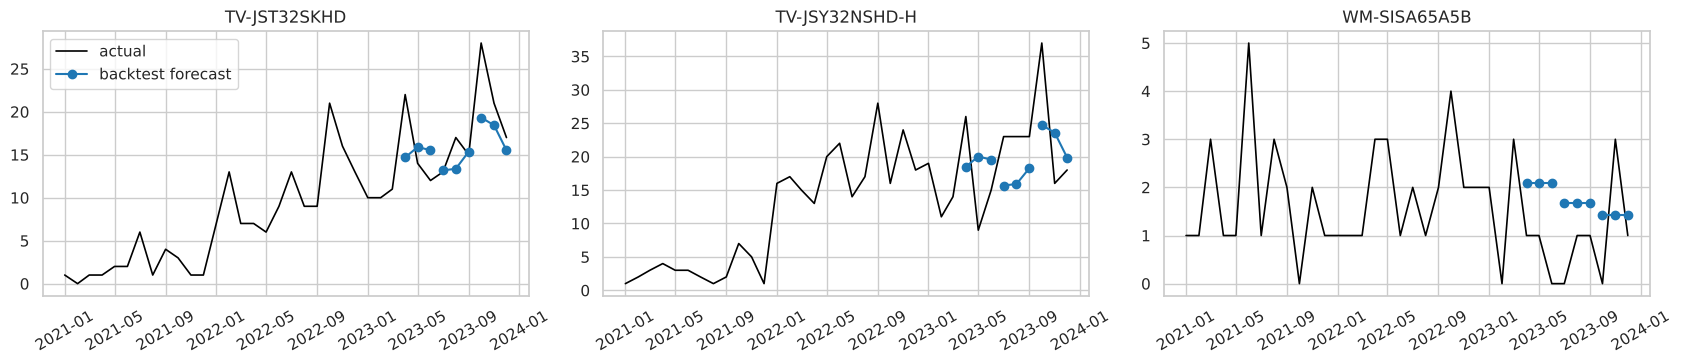

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 3.8))
for ax, sku in zip(axes, ['TV-JST32SKHD', 'TV-JSY32NSHD-H', 'WM-SISA65A5B']):
    ax.plot(Y.index, Y[sku], color='black', lw=1.2, label='actual')
    for _, r in bt[(bt.model == sku) & (bt.method == best[sku[:2]])].iterrows():
        ax.plot(r.months, r.fc, marker='o', color='tab:blue', label='backtest forecast' if r.origin == '2023-03-01' else None)
    ax.set_title(sku); ax.tick_params(axis='x', rotation=30)
axes[0].legend(); plt.tight_layout(); plt.show()

Top-down Holt-Winters wins for TVs (quarterly WAPE ~16% vs ~39% for seasonal naive): individual model series are too noisy, the category total is smooth. For washing machines nothing forecasts well, as expected with 0-3 units a month.

## 8. Investment rotation as an optimisation problem

"Allocate more to popular models" becomes a precise question: with a fixed budget for next quarter's stock, how many units of each model should the firm buy?

The intuition: buying too little of a model loses its margin; buying too much leaves unsold stock that ties up money. Demand is uncertain, so the LP looks at 500 possible demand outcomes at once and picks the quantities that do best on average, within the budget.

Two-stage stochastic linear program (sample average approximation over demand scenarios):

$$\max_{Q,s}\ \frac{1}{S}\sum_{k}\sum_i (m_i + h_i)\,s_{ik} - \sum_i h_i Q_i \quad \text{s.t.}\quad s_{ik}\le Q_i,\ s_{ik}\le D_{ik},\ \sum_i c_i Q_i \le B$$

* $m_i$ = margin per unit **after** paying for the money tied up in 45 days of stock plus the receivable (this is where the credit cycle enters the stock decision)
* $h_i$ = cost of carrying an unsold unit into the next quarter
* $D_{ik}$ = demand scenarios: negative binomial around the backtested forecast, dispersion estimated from backtest errors

Assumptions: cost of funds 11.5% p.a., holding cost 6% p.a., DSO = average from the simulation above.

In [33]:
R_FUNDS, HOLD, DIO = 0.115, 0.06, 45
DSO = summary.loc['Status quo (net 30, nothing enforced)', 'dso']
prod = products.set_index('model_code')

def economics(skus, dso=DSO):
    price = prod.loc[skus, 'dealer_rate'].values.astype(float); gm = prod.loc[skus, 'distributor_margin_pct'].values / 100
    cost = price * (1 - gm)
    return pd.DataFrame({'price': price, 'cost': cost, 'margin_net': price * gm - cost * R_FUNDS * (DIO + dso) / 365,
                         'carry_cost': cost * (HOLD + R_FUNDS) * 0.25}, index=skus)

def dispersion(cat):
    g = bt[(bt.category == cat) & (bt.method == best[cat])]; mu = g.forecast_q.clip(lower=0.5)
    return float(np.clip(np.average(((g.actual_q - mu) ** 2 - mu) / mu ** 2, weights=mu), 0.01, 2))
alpha = {c: dispersion(c) for c in ('TV', 'WM')}

def scenarios(mu, n):
    D = np.zeros((len(mu), n))
    for i, (sku, m_) in enumerate(mu.items()):
        r = 1 / alpha[sku[:2]]; D[i] = rng.negative_binomial(r, r / (r + max(m_, 0.05)), n)
    return D

def solve_lp(eco, D, budget):
    n, S = D.shape; m_, h, c = eco.margin_net.values, eco.carry_cost.values, eco.cost.values
    obj = np.concatenate([h, -np.repeat((m_ + h) / S, S)])
    rows = np.arange(n * S)
    A1 = hstack([coo_matrix((-np.ones(n * S), (rows, np.repeat(np.arange(n), S))), shape=(n * S, n)),
                 coo_matrix((np.ones(n * S), (rows, rows)), shape=(n * S, n * S))])
    A = vstack([A1, hstack([csr_matrix(c[None, :]), csr_matrix((1, n * S))])]).tocsr()
    res = linprog(obj, A_ub=A, b_ub=np.r_[np.zeros(n * S), budget],
                  bounds=[(0, None)] * n + [(0, d) for d in D.ravel()], method='highs')
    return res.x[:n], -res.ineqlin.marginals[-1]          # units, shadow price of the budget

def evaluate(eco, Q, D):
    Q = np.floor(Q + 1e-6)[:, None]; sold = np.minimum(Q, D); left = Q - sold
    profit = (eco.margin_net.values[:, None] * sold - eco.carry_cost.values[:, None] * left).sum(0)
    return {'profit': profit.mean(), 'fill_rate': sold.sum() / D.sum(), 'unsold_stock_value': (left * eco.cost.values[:, None]).sum(0).mean()}

def quarter_mu(train_end):
    Yt = Y.loc[:train_end]; fc = {}
    for cat in ('TV', 'WM'): fc.update(forecast(Yt, cat, best[cat], 3))
    return pd.Series({k: v.sum() for k, v in fc.items()})

def plan(train_end, last_year):
    mu = quarter_mu(train_end); eco = economics(list(mu.index))
    budget = 0.75 * (mu * eco.cost).sum()                 # capital-constrained: can fund 75% of expected demand
    Q, shadow = solve_lp(eco, scenarios(mu, 500), budget)
    w = Y.loc[last_year[0]:last_year[1], mu.index].sum().values   # what a manager would do: repeat last year's mix
    Qb = w / w.sum() * budget / eco.cost.values; Qb *= budget / (Qb * eco.cost.values).sum()
    return mu, eco, budget, Q, Qb, shadow

**Backtest first:** plan Q4 2023 using data up to September, then score both plans on the actual Q4 demand (which the model never saw).

In [34]:
mu, eco, budget, Q, Qb, shadow = plan('2023-09-01', ('2022-10-01', '2022-12-01'))
actual_q4 = Y.loc['2023-10-01':'2023-12-01', mu.index].sum().values[:, None]
print(f'budget INR {budget/1e5:.1f} lakh')
pd.DataFrame({'optimised LP': evaluate(eco, Q, actual_q4), "last year's mix": evaluate(eco, Qb, actual_q4)}).T.round(2)

budget INR 58.8 lakh


,profit,fill_rate,unsold_stock_value
optimised LP,154164.76,0.69,22896.5
last year's mix,87692.41,0.63,968621.5


Q1 2024 budget INR 62.0 lakh | shadow price: one more rupee of stock budget earns 1.9 paise


,profit,fill_rate,unsold_stock_value
optimised LP,158321.32,0.74,83481.06
last year's mix,120741.39,0.75,615513.52


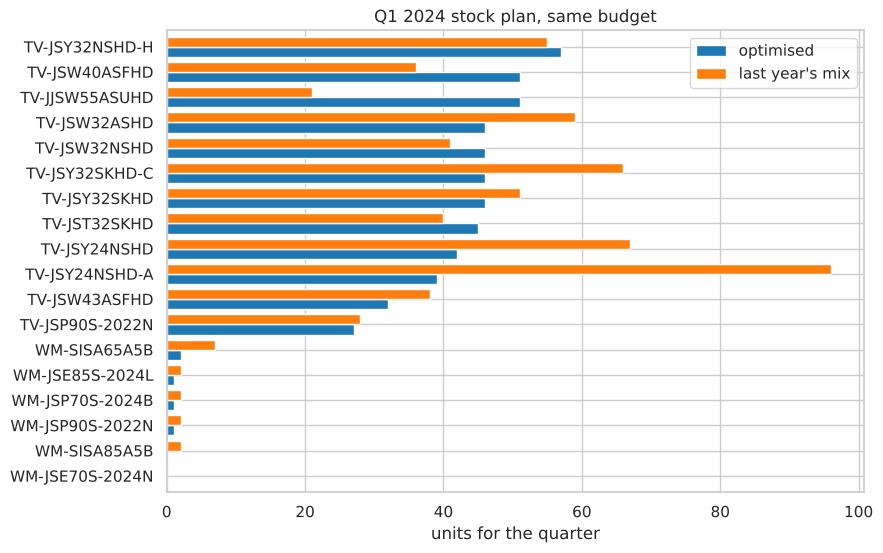

In [35]:
mu, eco, budget, Q, Qb, shadow = plan('2023-12-01', ('2023-01-01', '2023-03-01'))
D_test = scenarios(mu, 5000)
print(f'Q1 2024 budget INR {budget/1e5:.1f} lakh | shadow price: one more rupee of stock budget earns {100*shadow:.1f} paise')
q1_opt, q1_base = evaluate(eco, Q, D_test), evaluate(eco, Qb, D_test)
display(pd.DataFrame({'optimised LP': q1_opt, "last year's mix": q1_base}).T.round(2))

alloc = pd.DataFrame({'forecast': mu.round(1), 'optimised': np.floor(Q), "last year's mix": np.floor(Qb)}).sort_values('optimised')
alloc[['optimised', "last year's mix"]].plot(kind='barh', figsize=(9, 6), width=0.8)
plt.xlabel('units for the quarter'); plt.title('Q1 2024 stock plan, same budget'); plt.show()

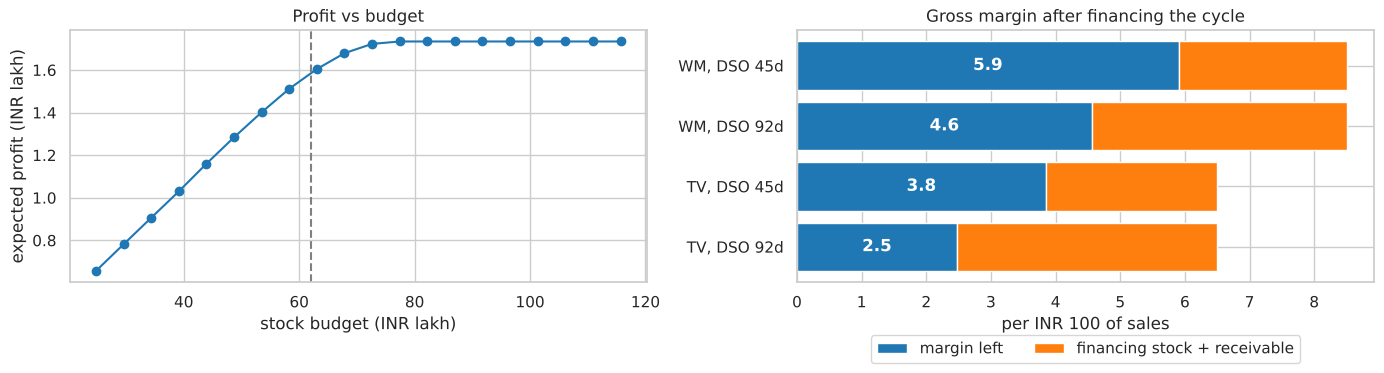

In [36]:
budgets = np.linspace(0.3, 1.4, 20) * budget / 0.75
D_fit = scenarios(mu, 500)
curve = [(b, evaluate(eco, solve_lp(eco, D_fit, b)[0], D_test)['profit'], solve_lp(eco, D_fit, b)[1]) for b in budgets]
curve = pd.DataFrame(curve, columns=['budget', 'profit', 'shadow'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(curve.budget / 1e5, curve.profit / 1e5, marker='o'); axes[0].axvline(budget / 1e5, color='grey', ls='--')
axes[0].set_xlabel('stock budget (INR lakh)'); axes[0].set_ylabel('expected profit (INR lakh)'); axes[0].set_title('Profit vs budget')

# how much of the gross margin the credit cycle eats
for i, (cat, gm) in enumerate([('TV', 0.065), ('WM', 0.085)]):
    for j, d in enumerate([DSO, 45]):
        cyc = 100 * (1 - gm) * R_FUNDS * (DIO + d) / 365
        y0 = i * 2 + j
        axes[1].barh(y0, 100 * gm - cyc, color='tab:blue'); axes[1].barh(y0, cyc, left=100 * gm - cyc, color='tab:orange')
        axes[1].text((100 * gm - cyc) / 2, y0, f'{100*gm - cyc:.1f}', color='white', ha='center', va='center', fontweight='bold')
axes[1].set_yticks(range(4), [f'TV, DSO {DSO:.0f}d', 'TV, DSO 45d', f'WM, DSO {DSO:.0f}d', 'WM, DSO 45d'])
axes[1].legend(['margin left', 'financing stock + receivable'], loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2)
axes[1].set_xlabel('per INR 100 of sales'); axes[1].set_title('Gross margin after financing the cycle')
plt.tight_layout(); plt.show()

* On held-out Q4 2023 demand the LP plan earns noticeably more than repeating last year's mix and leaves far less unsold stock, with the same capital.
* The profit curve flattens beyond the plan budget: the shadow price says how much an extra rupee of working capital is worth, which is a better way to decide on a bigger OD limit than gut feel.
* The right panel connects the two problems: at a ~92-day DSO, financing the cycle eats ~60% of the TV gross margin. Getting DSO to 45 days is worth more than any change in model mix.

## 9. Part 1 vs Part 2

| Topic | Part 1 | Part 2 |
|---|---|---|
| Payment trend | Dealers who cleared their dues fell 82.8% -> 55.2% -> 37.9%; paying dealers' median flat at 56.5 days | Payment is slowing, but the flat median came from ignoring unpaid invoices. Counting them, the median goes **59 -> 74 -> 95 days**. On a fair, fixed 120-day window, **86% -> 67% -> 55%** of invoices were paid |
| Predicting late payment | Logistic regression, ROC-AUC ~0.80 | That score relied on future information and a random split. Tested honestly it falls to about 0.74; a scorecard built on point-in-time features (especially the **age of the dealer's oldest unpaid bill**) reaches ~0.83 |
| Problem dealers | 13 dealers with dues uncleared for two or more periods; 3 segments | Four behaviour segments, including five **chronic defaulters** who have paid almost nothing since 2022 |
| Discount / penalty | Offer 3% for paying within 30 days, charge 9% after | No discount adds value: retailers' money costs more than the firm's, and early payers pocket it. **Overdue interest plus a credit hold for chronic defaulters** is the best policy and beats the status quo in every simulation |
| Investment rotation | Invest more in the nine "growing" TV models | Only one of them is genuinely gaining share. A forecast-driven stock plan beats last year's mix on held-out data with far less unsold stock. **Shortening the credit cycle is worth more than changing the mix** |
| Rollout | Not addressed | A power analysis shows the firm is too small for an A/B test to prove an effect; a stepped rollout with guardrails is the safer design |

## 10. Action plan for the firm

Every step below uses tools a small Jaipur distributor already has: Tally, a phone with WhatsApp, the salesman who visits dealers, and a spreadsheet. None needs new software or extra staff.

| # | Action | How, in practice | Who | Start |
|---|---|---|---|---|
| 1 | **Weekly overdue list** | Every Monday, print Tally's outstanding-receivables report with ageing, sorted by oldest bill | Accountant | Week 1 |
| 2 | **Collection calendar** | WhatsApp reminder 5 days before the 30-day due date; phone call at day 35; salesman collects the cheque in person at day 50 | Accountant, salesman | Week 1 |
| 3 | **Dispatch rule** | Before billing a dealer, check their oldest unpaid bill. If it is over 60 days old, dispatch only after a part-payment or a post-dated cheque (PDC). Enter each dealer's credit limit and credit period in their Tally ledger so billing shows a warning when they are exceeded | Owner, billing staff | Month 1 |
| 4 | **Advance-only for the five chronic defaulters** | Deepanshi Electronics, Jai Shree Shyam, Radhika Air & Vision, Riddhi Siddhi Enterprises and Shri Govindam Electronics buy against advance payment until old dues are cleared. Offer each a written instalment plan backed by PDCs; send a legal notice where nothing is paid after 180 days | Owner | Month 1 |
| 5 | **Interest on overdue bills** | Print "Interest @ 18% p.a. on bills unpaid after 45 days" on every invoice and announce it at a dealer meet. In the first months use it as leverage: raise a debit note only on repeat offenders, and waive it for dealers who stick to their payment plan | Owner, accountant | Month 2 |
| 6 | **Monthly dealer review** | A one-page sheet per dealer: average days to pay (last 6 months), age of oldest unpaid bill, share of invoices paid within 60 days. Use the scorecard bands (A preferred, B standard, C watch, D hold) to raise or freeze credit limits each quarter | Owner | Month 2 |
| 7 | **Drop the early-payment discount idea** | Don't offer the 3% discount. If a dealer asks for one, offer a better credit limit for consistently paying on time instead | Owner | Now |
| 8 | **Quarterly purchase plan** | Before each quarter, forecast total TV demand from monthly sales history (with the festive peak), split it by each model's recent share, and cap the order at the available budget (section 8). Order washing machines only against confirmed dealer orders, keeping 1-2 units per model. Review TV-JSP90S-2022N, which is losing share | Owner | Next quarter |
| 9 | **Five numbers every month** | DSO, % of invoices paid within 60 days, amount overdue more than 90 days, unsold stock value, sales to A/B-band dealers | Accountant | Month 1 |

**Considered and not recommended:** invoice factoring or discounting (suggested in Part 1). Platforms such as TReDS are built around large corporate or government buyers; Anuratna's buyers are small retailers, so finance against these receivables is unlikely to be available on reasonable terms. Fixing collections is cheaper.

### Why would dealers comply instead of switching?

The plan only works if dealers accept the new terms, so it is worth asking why they would.

* **There is no other Sansui source in Jaipur.** Anuratna is the sole Sansui distributor in the city. A dealer can drop Sansui for another brand, but if its customers want the cheapest brand in each size, Sansui is hard to replace.
* **The rules only bite on dealers who don't pay.** A dealer paying within 45-60 days never meets the dispatch block or the interest clause. The dealers most likely to leave are the chronic defaulters and heavy arrears carriers, and losing a dealer who takes stock without paying improves profit (section 6 already includes this churn).
* **Other distributors are not softer.** Every distributor in the market faces late payment. A dealer with large unpaid dues is unlikely to get generous credit elsewhere, and switching brings costs of its own: a new relationship, leftover stock of the old brand, warranty and service tie-ups.
* **Compliance is rewarded, not just lateness punished:**
  * higher credit limits for A/B-band dealers;
  * first allocation of fast-moving models in the festive season, when stock runs short;
  * brand schemes and new models offered first to dealers in good standing.
* **Rollout is gradual.** Announce the terms at a dealer meet, give one to two months' notice, and enforce strictly on the worst cases first. Use overdue interest as leverage and waive it for dealers who keep to a payment plan.

Realistically the firm should expect to lose one or two dealers; the simulation shows the plan still comes out ahead.

### 10.1 Test before rolling out: pilot design (A/B test)

Changing credit terms for all 29 dealers at once is risky: if the reminder routine and dispatch rule don't help, or upset good dealers, the firm finds out too late. The safer route is a **controlled pilot**: apply the routine to a random half of the dealers for a few months, keep the other half on current terms, and compare.

Design choices:
* **Who is in it:** the 24 dealers outside the chronic-defaulter group (those five move to advance-only regardless).
* **Randomisation within segments** (stratified), so both arms get a similar mix of reliable, erratic and slow payers.
* **Primary metric:** share of invoices paid within 60 days, per dealer, over the pilot window. Secondary: average days to pay, amount overdue beyond 90 days.
* **Analysis:** compare arms while adjusting for each dealer's own pre-pilot value (ANCOVA). Dealers differ a lot from each other, and the adjustment removes much of that noise.

The key question is **power**: with only 24 dealers, how big an improvement could the pilot reliably detect?

In [37]:
# 1) stratified random assignment
pilot = seg[seg.segment != 'Chronic defaulters'][['dealer_code', 'dealer_name', 'segment']].copy()
assign_rng = np.random.default_rng(2024)
pilot['arm'] = ''
for s_, g_ in pilot.groupby('segment'):
    order = assign_rng.permutation(g_.index)
    pilot.loc[order[0::2], 'arm'] = 'treatment'
    pilot.loc[order[1::2], 'arm'] = 'control'
display(pd.crosstab(pilot.segment, pilot.arm, margins=True))

# 2) how noisy is the metric between dealers, and how much does a dealer's past predict its future?
def dealer_paid60(start, end):
    w = df[df.dealer_code.isin(pilot.dealer_code) & df.invoice_date.between(start, end)]
    return w.groupby('dealer_code').apply(lambda x: ((x.event == 1) & (x.duration <= 60)).mean(), include_groups=False)

from scipy.stats import norm
z = norm.ppf(0.975) + norm.ppf(0.80)          # 5% significance, 80% power
n_arm = len(pilot) / 2
rows = []
for months, windows in {3: [('2023-01-01', '2023-03-31'), ('2023-04-01', '2023-06-30')],
                        6: [('2022-10-01', '2023-03-31'), ('2023-04-01', '2023-09-30')]}.items():
    pre, post = dealer_paid60(*windows[0]), dealer_paid60(*windows[1])
    both = pd.concat([pre, post], axis=1, keys=['pre', 'post']).dropna()
    sd, rho = both.post.std(), both.pre.corr(both.post)
    rows.append({'pilot length (months)': months, 'between-dealer SD of metric': sd, 'pre/post correlation': rho,
                 'detectable effect, simple comparison (pp)': 100 * z * sd * np.sqrt(2 / n_arm),
                 'detectable effect, with ANCOVA (pp)': 100 * z * sd * np.sqrt(2 * (1 - rho ** 2) / n_arm)})
power = pd.DataFrame(rows).set_index('pilot length (months)')
power.round(3)

arm,control,treatment,All
segment,,,
Erratic payers,3,3,6
Reliable payers,2,2,4
"Slow, carrying arrears",7,7,14
All,12,12,24


,between-dealer SD of metric,pre/post correlation,"detectable effect, simple comparison (pp)","detectable effect, with ANCOVA (pp)"
pilot length (months),,,,
3,0.441,0.356,50.414,47.117
6,0.408,0.284,46.615,44.689


**A dealer-level comparison can't work here.** The share of invoices paid within 60 days swings enormously from dealer to dealer (standard deviation around 0.4), so with 12 dealers per arm only an improvement of roughly **45 percentage points** would show up reliably. Adjusting for each dealer's past barely helps, because a dealer's past and future quarters are only weakly correlated (around 0.3). The plan is expected to move this metric by about **+10 points** (section 11), far below that threshold.

Two changes give the test a better chance:
* **Analyse invoices, not dealer averages.** Every invoice is an observation, with standard errors clustered by dealer.
* **Compare each dealer with itself** through a **stepped rollout**: half the dealers (chosen at random within segments) start the new routine in month 1, the other half join in month 4. Dealer and period fixed effects then remove the between-dealer noise. Nobody has the routine switched off once started, which matters because dealers who learn the new rules don't unlearn them.

The simulation below plants a known improvement in the historical invoices, re-runs the randomisation 300 times, and counts how often the test detects it.

In [38]:
# 3) simulation-based power at invoice level: parallel arms vs a staggered (stepped) rollout
def pilot_window(start, switch, end):
    w = df[df.dealer_code.isin(pilot.dealer_code) & df.invoice_date.between(start, end)].copy()
    w['y'] = ((w.event == 1) & (w.duration <= 60)).astype(float)
    w['second_half'] = (w.invoice_date >= switch).astype(int)
    return w

def power_sim(delta, design, win, n_rep=300):
    base_rate = win.y.mean()
    dealer_dummies = pd.get_dummies(win.dealer_code, drop_first=True).astype(float)
    hits = 0
    for r in range(n_rep):
        rr = np.random.default_rng(r)
        arm = {}
        for _, g_ in pilot.groupby('segment'):                      # stratified randomisation every repetition
            ids = rr.permutation(g_.dealer_code.values)
            arm.update({d: int(k % 2 == 0) for k, d in enumerate(ids)})
        a = win.dealer_code.map(arm).values
        # parallel: arm 1 treated for all 6 months | stepped: arm 1 from month 1, arm 0 joins in month 4
        treat = a if design == 'parallel' else np.where(win.second_half == 1, 1, a)
        y = win.y.values.copy()
        y[(treat == 1) & (y == 0) & (rr.random(len(y)) < delta / (1 - base_rate))] = 1   # true effect: +delta
        if design == 'parallel':
            X = sm.add_constant(pd.DataFrame({'treat': treat, 'second_half': win.second_half.values}, index=win.index))
        else:   # each dealer compared with itself: dealer and period fixed effects
            X = sm.add_constant(dealer_dummies.assign(second_half=win.second_half.values, treat=treat))
        fit = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': win.dealer_code.values})
        hits += (fit.pvalues['treat'] < 0.05) and (fit.params['treat'] > 0)
    return hits / n_rep

w6 = pilot_window('2023-04-01', '2023-07-01', '2023-09-30')     # 6-month pilot, second group joins in month 4
w12 = pilot_window('2023-01-01', '2023-07-01', '2023-12-31')    # 12-month pilot, second group joins in month 7
print(f'6 months: {len(w6)} invoices, {w6.y.mean():.0%} paid within 60 days | 12 months: {len(w12)} invoices')
deltas = (0.05, 0.10, 0.15, 0.20)
pw = pd.DataFrame({'Parallel arms, 6 months': [power_sim(d, 'parallel', w6) for d in deltas],
                   'Stepped rollout, 6 months': [power_sim(d, 'stepped', w6) for d in deltas],
                   'Stepped rollout, 12 months': [power_sim(d, 'stepped', w12) for d in deltas]},
                  index=[f'+{int(100*d)} pp' for d in deltas])
pw.index.name = 'true improvement in % paid within 60 days'
pw.style.format('{:.0%}')

6 months: 226 invoices, 29% paid within 60 days | 12 months: 461 invoices


,"Parallel arms, 6 months","Stepped rollout, 6 months","Stepped rollout, 12 months"
true improvement in % paid within 60 days,,,
+5 pp,1%,11%,7%
+10 pp,5%,17%,15%
+15 pp,10%,27%,28%
+20 pp,19%,37%,46%


**What the power analysis says:**
* A parallel A/B test with 24 dealers is essentially blind: even a +20 point improvement would be detected less than a fifth of the time.
* The stepped rollout roughly doubles the power, but a realistic +10 point effect is still detected only about one time in six. Running it for 12 months barely helps, because the two groups differ only during the stagger.

**So the honest conclusion is that this firm is too small to *prove* the effect with a significance test.** That doesn't mean skipping the pilot. It changes what the pilot is for:

1. **Stepped rollout as a safety check.** If the routine causes problems (good dealers complaining, orders dropping), they surface in the first group while the second can still be held back.
2. **Guardrail metrics with stop rules.** Pause and review if monthly sales to A/B-band dealers fall more than 10% against the comparison group, or if more than one good dealer stops ordering.
3. **Report an estimate, not a verdict.** At month 6, report the estimated change in % paid within 60 days with its confidence interval, alongside the five monthly numbers from action 9. The decision to keep the routine rests on that direction of evidence plus the guardrails, not on p < 0.05.
4. **Use more sensitive metrics where possible.** Days to pay as a continuous number carries more information than a paid/not-paid flag, and should be the secondary readout.

## 11. Expected outcomes

What could the firm expect in the first year after putting the plan in place? I estimate this from the models above, using 2023 as the baseline year and three scenarios:

* **Credit policy (actions 3-5):** from the Monte Carlo simulation in section 6, comparing "interest after 45 days + credit hold" with the status quo across the same 1,000 scenarios. Conservative / expected / optimistic = 10th / 50th / 90th percentile of the improvement.
* **Collection routine (actions 1-2):** the simulation does not model reminders and visits. I assume they pull payments forward by **10 / 15 / 20 days** on average. Even the optimistic case leaves dealers paying after ~70 days, far outside the 30-day terms, so this is a modest assumption.
* **Purchase planning (action 8):** quarterly results from section 8, times four. The conservative case assumes the firm follows the plan only half the time.

These are **projections from the models**, not measured results.

In [39]:
BILLING = A.sum()                                     # 2023 credit sales (INR)
live = A[segs != 'Chronic defaulters'].sum()          # sales still made once chronic defaulters move to advance-only
sq_s, rec_s = sims['Status quo (net 30, nothing enforced)'], sims['Interest after 45d + credit hold']
L = 1e5                                               # INR -> lakh

# credit policy: paired improvement over identical scenarios
gain = (rec_s.net_per_100 - sq_s.net_per_100) / 100 * BILLING
bad_today, bad_after = sq_s['bad_debt_%'] / 100 * BILLING, rec_s['bad_debt_%'] / 100 * live

# collection routine
shift = {'Conservative': 10, 'Expected': 15, 'Optimistic': 20}
km3 = kms['P3']
paid60_today = 1 - S_at(km3, 60)

# purchase planning
stock_gain_q = q1_opt['profit'] - q1_base['profit']
adoption = {'Conservative': 0.5, 'Expected': 1.0, 'Optimistic': 1.0}

rows = {
    'Net contribution from credit sales (INR lakh / yr)':
        [sq_s.net_per_100.mean() / 100 * BILLING / L] + [(sq_s.net_per_100.mean() / 100 * BILLING + gain.quantile(q)) / L for q in (.1, .5, .9)],
    'Bad debt written off (INR lakh / yr)':
        [bad_today.mean() / L] + [bad_after.quantile(q) / L for q in (.9, .5, .1)],
    'Sales moved to advance-only (INR lakh / yr)':
        [0] + [(BILLING - live) / L] * 3,
    'Average days to pay, paying invoices':
        [sq_s.dso.mean()] + [rec_s.dso.mean() - d for d in shift.values()],
    'Invoices paid within 60 days (%)':
        [100 * paid60_today] + [100 * (1 - S_at(km3, 60 + d)) for d in shift.values()],
    'Cash released from receivables, one-time (INR lakh)':
        [0] + [live * d / 365 / L for d in shift.values()],
    'Interest saved on released cash (INR lakh / yr)':
        [0] + [live * d / 365 * R_FUNDS / L for d in shift.values()],
    'Unsold stock at quarter end (INR lakh)':
        [q1_base['unsold_stock_value'] / L] + [(q1_base['unsold_stock_value'] - a * (q1_base['unsold_stock_value'] - q1_opt['unsold_stock_value'])) / L for a in adoption.values()],
    'Extra profit from purchase planning (INR lakh / yr)':
        [0] + [4 * a * stock_gain_q / L for a in adoption.values()],
}
outcomes = pd.DataFrame(rows, index=['Today (2023)', 'Conservative', 'Expected', 'Optimistic']).T
outcomes.round(1)

,Today (2023),Conservative,Expected,Optimistic
Net contribution from credit sales (INR lakh / yr),-6.0,2.6,4.5,6.5
Bad debt written off (INR lakh / yr),23.3,16.0,11.9,8.4
Sales moved to advance-only (INR lakh / yr),0.0,15.7,15.7,15.7
"Average days to pay, paying invoices",91.7,79.3,74.3,69.3
Invoices paid within 60 days (%),26.5,34.0,37.9,40.8
"Cash released from receivables, one-time (INR lakh)",0.0,7.8,11.7,15.7
Interest saved on released cash (INR lakh / yr),0.0,0.9,1.3,1.8
Unsold stock at quarter end (INR lakh),6.2,3.5,0.8,0.8
Extra profit from purchase planning (INR lakh / yr),0.0,0.8,1.5,1.5


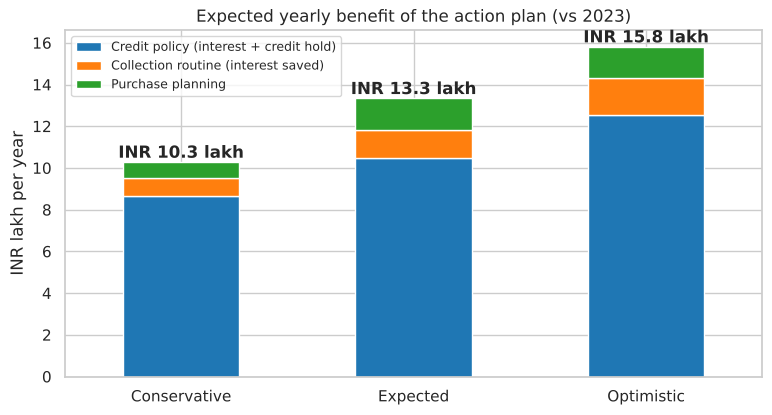

Expected total: about INR 13.3 lakh a year on INR 301 lakh of sales, plus a one-time INR 11.7 lakh of cash released from receivables.


In [40]:
benefit = pd.DataFrame({
    'Credit policy (interest + credit hold)': [gain.quantile(q) / L for q in (.1, .5, .9)],
    'Collection routine (interest saved)': [live * d / 365 * R_FUNDS / L for d in shift.values()],
    'Purchase planning': [4 * a * stock_gain_q / L for a in adoption.values()],
}, index=list(shift))
benefit.plot(kind='bar', stacked=True, figsize=(9, 4.5), rot=0)
for i, tot in enumerate(benefit.sum(axis=1)):
    plt.text(i, tot + 0.2, f'INR {tot:.1f} lakh', ha='center', fontweight='bold')
plt.ylabel('INR lakh per year'); plt.title('Expected yearly benefit of the action plan (vs 2023)')
plt.legend(loc='upper left', fontsize=9); plt.show()

print(f"Expected total: about INR {benefit.loc['Expected'].sum():.1f} lakh a year on INR {BILLING/L:.0f} lakh of sales, "
      f"plus a one-time INR {live*15/365/L:.1f} lakh of cash released from receivables.")

**Reading the outcomes**

* The biggest gain comes from **not lending to dealers who don't pay back**: moving the five chronic defaulters to advance-only gives up a few lakh of sales, but those sales were mostly turning into bad debt.
* The collection routine mainly **frees cash**. That cash can repay the bank overdraft (the interest saving above) or fund more stock in the festive season, where the stock plan shows extra budget earns a return.
* Purchase planning is a smaller rupee gain, but it is the one that **cuts dead stock** sharply, which matters for models that are being phased out.
* For a distributor earning 6-8% gross margin, moving from a net loss on credit sales to a small positive contribution is the difference between growth funded by the bank and growth funded by the business.

## 12. Limitations and next steps

* **Representative data.** The notebook runs on a representative dataset that reproduces the firm's summary figures; invoice-level detail, prices, margins, credit limits and competitor prices are estimates, so effect sizes are indicative.
* **Assumed financial parameters:** cost of funds 11.5% a year, retailer cost of money 14-26%, recovery on bad debt 20-50%, penalty enforcement 30-70%. Each is a single line of code to change.
* **Simple behaviour model.** Dealers in the simulation respond rationally to incentives; real dealers also respond to relationships and habit.
* **Small sample.** 29 dealers is enough for patterns but thin for segmentation.
* **Next steps with real data:** run the notebook on the actual Tally export (invoice and receipt registers, plus monthly stock levels); refit the scorecard every quarter; track the five monthly numbers from action 9 to measure the real effect of each action.